# pyWellSFM — synthetic case study

This notebook reproduces the synthetic case study of the pyWellSFM paper
(section 5.2). A synthetic case has one property that no real case offers:
**the truth is known**. The notebook uses it to show, in five steps of
increasing complexity:

| Step | Setup | What it shows |
|---|---|---|
| 0. Minimal run | 1 well on the rimmed (protected) carbonate platform preset, 5 organism-based elements, constant subsidence, two-frequency eustasy | Simple usage of the library and the main outputs |
| 1. Verification | Deterministic configuration with an analytical solution; decreasing time-step tolerance | The code solves the stated equations; first-order convergence of the adaptive time stepping |
| 2. Stochastic behaviour | 50 realizations, environment-selector likelihoods switched on one at a time | What each likelihood (water depth, transition, trend) adds to the environment and composition successions |
| 3. Multi-well transect | 3 wells sharing one scenario, different initial water depth and subsidence | Scenario vs realization; diachronous environment belts |
| 4. Closed loop + sweep | Degraded "observed" well; accommodation recovery; brute-force sweep of eustasy, subsidence and production | Recovery error of the inverse calculator; non-uniqueness; runtime |

The geological setting is a generic Early Cretaceous (Urgonian-type) rimmed
carbonate platform; ages in Ma are illustrative. All runs are seeded and the
notebook regenerates every figure and table of the synthetic case. Figures are
saved in `notebooks/.outputs/synthetic_case`. Each figure is followed by a
caption that describes its panels, what the figure is meant to show, what is
observed and how it is interpreted.

## Setup

In [ ]:
import os
import platform
import sys
import time

root_path = os.path.dirname(os.getcwd())
package_path = os.path.join(root_path, "src")
if package_path not in sys.path:
    sys.path.insert(0, package_path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Patch, Rectangle

import pywellsfm
from pywellsfm import (
    AccommodationSpaceWellCalculator,
    AccumulationCurve,
    AccumulationModel,
    AccumulationModelElementOptimum,
    CarbonateProtectedRampDepositionalEnvironmentModel,
    Curve,
    DESimulatorParameters,
    FSSimulator,
    FSSimulatorParameters,
    Marker,
    RealizationData,
    Scenario,
    SubsidenceType,
    Well,
)
from pywellsfm.algorithms import (
    embeddedMarkovChiSquareTest,
    faciesFromDepositionalEnvironments,
    faciesMismatchFraction,
    markerDepthRmse,
    pooledTransitionCountMatrix,
    resampleStriplog,
    runParameterSweep,
    simulatedAgesToDepths,
    simulatedStepEndDepths,
    striplogToSequence,
    thicknessProportionDistance,
    thicknessProportions,
    transitionProbabilityMatrix,
)

# the simulator logs every time step at INFO level: keep errors only
pywellsfm.set_log_level(pywellsfm.ERROR)

OUTPUT_DIR = os.path.join(os.getcwd(), ".outputs/synthetic_case")
os.makedirs(OUTPUT_DIR, exist_ok=True)

plt.rcParams.update(
    {
        "figure.dpi": 110,
        "savefig.dpi": 300,
        "font.size": 8,
        "axes.titlesize": 9,
        "axes.labelsize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)


def save_figure(fig, name):
    """Save a figure as PNG and PDF in the output directory."""
    for ext in ("png", "pdf"):
        fig.savefig(os.path.join(OUTPUT_DIR, f"{name}.{ext}"), bbox_inches="tight")


print(f"pyWellSFM {pywellsfm.__version__} - Python {platform.python_version()}")

pyWellSFM 0.1.0 - Python 3.13.16


### Display conventions

Depositional environments are ordered from proximal to distal and coloured from
brown (exposed) to dark blue (basin). Elements (carbonate producers and clay)
have their own palette.

In [2]:
ENVIRONMENTS = ["Continent", "TidalFlat", "Lagoon", "BackReef", "ReefFlat", "ForeReef", "OuterPlatform", "Basin"]
ENV_SHORT = {
    "Continent": "CON",
    "TidalFlat": "TID",
    "Lagoon": "LAG",
    "BackReef": "BRF",
    "ReefFlat": "RFL",
    "ForeReef": "FRF",
    "OuterPlatform": "OUT",
    "Basin": "BAS",
}
ENV_COLORS = {
    "Continent": "#8d6e63",
    "TidalFlat": "#d7ccc8",
    "Lagoon": "#fff59d",
    "BackReef": "#ffcc80",
    "ReefFlat": "#e57373",
    "ForeReef": "#9ccc65",
    "OuterPlatform": "#4fc3f7",
    "Basin": "#0d47a1",
    "none": "#ffffff",
}
ELEMENTS = ["foraminifera", "rudist", "coral", "echinoderm", "clay"]
ELEMENT_COLORS = {
    "foraminifera": "#f0e442",
    "rudist": "#e69f00",
    "coral": "#d55e00",
    "echinoderm": "#009e73",
    "clay": "#56708a",
    "Unclassified": "#ffffff",
}
COLORS = {**ENV_COLORS, **ELEMENT_COLORS}


def env_legend_handles(names=ENVIRONMENTS):
    return [Patch(facecolor=ENV_COLORS[n], edgecolor="k", lw=0.3, label=f"{ENV_SHORT[n]} - {n}") for n in names]


def element_legend_handles(names=ELEMENTS):
    return [Patch(facecolor=ELEMENT_COLORS[n], edgecolor="k", lw=0.3, label=n) for n in names]


def plot_depth_column(ax, log, x0=0.0, width=1.0, component="lithology"):
    """Draw a discrete depth log as coloured boxes (depth increases downward)."""
    for iv in log:
        label = iv.primary[component]
        ax.add_patch(
            Rectangle(
                (x0, iv.top.z),
                width,
                iv.base.z - iv.top.z,
                facecolor=COLORS.get(label, "#cccccc"),
                edgecolor="none",
            )
        )


def plot_time_column(ax, times, dts, envs, x0=0.0, width=1.0):
    """Draw environments in the time domain (one box per time step)."""
    for t, dt, env in zip(times, dts, envs):
        ax.add_patch(Rectangle((x0, t - dt), width, dt, facecolor=COLORS.get(str(env), "#cccccc"), edgecolor="none"))


HIATUS_COLOR = "#101ff8"


def hiatus_depths(well, merge_within=0.3):
    """Depths of the hiatus surfaces recorded by the simulator in a simulated well.

    Hiatuses closer than merge_within (m) are drawn as a single surface.
    """
    depths = sorted(m.depth for m in well.getMarkers() if m.name.startswith("Hiatus_"))
    merged = []
    for d in depths:
        if not merged or d - merged[-1] > merge_within:
            merged.append(d)
    return np.array(merged)


def draw_hiatus(ax, depths, x0=0.0, x1=1.0, n_waves=3, amplitude=0.5, across=False, lw=0.8, alpha=1.0):
    """Blue wavy line at each hiatus depth, from x0 to x1 (data units), or across the axes."""
    from matplotlib.transforms import blended_transform_factory

    transform = blended_transform_factory(ax.transAxes, ax.transData) if across else ax.transData
    if across:
        x0, x1 = 0.0, 1.0
    x = np.linspace(x0, x1, 25 * n_waves)
    for d in depths:
        y = d + amplitude * np.sin(2 * np.pi * n_waves * (x - x0) / (x1 - x0))
        ax.plot(x, y, color=HIATUS_COLOR, lw=lw, alpha=alpha, zorder=5, transform=transform, clip_on=True)


def hiatus_legend_handle():
    return plt.Line2D([], [], color=HIATUS_COLOR, lw=0.8, label="Hiatus")

## Step 0 — Minimal run: one well, one scenario

A pyWellSFM simulation is made of one **scenario** (what is shared by all wells
of an area: eustasy, accumulation laws, depositional environments) and one or
several **realizations** (what is specific to a well or to a hypothesis: initial
water depth, subsidence). The next three cells build the whole model
explicitly.

### Depositional environments

The setting is a rimmed carbonate platform, given by the
`CarbonateProtectedRampDepositionalEnvironmentModel` preset of pyWellSFM. From
proximal to distal: tidal flat, restricted lagoon, back-reef (open inner
platform with rudist shoals), reef flat (coral-rudist margin), fore-reef, outer
platform and basin. Each environment has a water-depth range (parameterized by
tidal range, wave-breaking depth, wave bases and shelf break), ranges of
energy and salinity (0-1, drawn uniformly at each step) and a distality.

The preset also contains a `Buildup` environment (lagoonal patch reefs) with
the same water-depth range and distality as the lagoon but a lower weight in
the prior probabilities. It is removed here to keep the case simple: the
rudist and coral producers are already represented by the back-reef and reef
flat.

The key property of this setting is that **lagoon, back-reef and reef flat all
lie in 0-10 m of water**: water depth alone cannot tell them apart. They differ
by their energy and salinity, which control what is produced, and by their
position along the proximal-distal profile, which the transition and trend
likelihoods of the environment selector exploit (Walther's law).

In [3]:
environment_model = CarbonateProtectedRampDepositionalEnvironmentModel()  # default water depth limits
environment_model.removeEnvironment("Buildup")  # not used in the synthetic case
pd.DataFrame(
    [
        {
            "environment": e.name,
            "water depth (m)": f"{e.waterDepth_min:g} - {e.waterDepth_max:g}",
            "distality": e.distality,
            **{
                name: f"{m.minValue:g} - {m.maxValue:g}"
                for name, m in e.envConditionsModel.envConditionModels.items()
            },
        }
        for e in environment_model.environments
    ]
).set_index("environment")

,water depth (m),distality,energy,salinity
environment,,,,
Continent,-10000 - -1,-1.0,NaN,NaN
TidalFlat,-1 - 1,0.0,0.1 - 0.3,0.6 - 1
Lagoon,1 - 10,1.0,0 - 0.2,0.3 - 0.7
BackReef,0 - 10,2.0,0.3 - 0.6,0.1 - 0.3
ReefFlat,0 - 8,3.0,0.7 - 1,0 - 0.1
ForeReef,5 - 40,4.0,0.3 - 0.6,0 - 0.1
OuterPlatform,30 - 200,5.0,0 - 0.2,0 - 0.1
Basin,200 - 10000,6.0,0 - 0,0 - 0.1


### Elements: what is produced and accumulated

Elements are defined by their **biotic (or detrital) composition**, i.e. by the
carbonate factory that produces them, rather than by a texture. Each element
has a maximum accumulation rate (m/Myr) reduced by coefficients (0-1) that
depend on the environmental conditions ("environment-optimum" law):

| Element | Organisms / origin | Optimum | Max. rate (m/Myr) |
|---|---|---|---|
| foraminifera | miliolids, orbitolinids, peloidal mud | 0-5 m, low energy, tolerant to restriction (salinity) | 24 |
| rudist | requieniid and monopleurid rudists | 2-10 m, moderate energy, normal salinity | 48 |
| coral | corals and microbial crusts | 0-10 m, high energy, normal salinity | 60 |
| echinoderm | crinoids, bryozoans, red algae (heterozoan bioclasts) | 10-40 m, low to moderate energy, normal salinity | 30 |
| clay | hemipelagic marl (detrital clay, plankton) | > 20 m, low energy | 12 |

Because coral, rudist and foraminifera share the same water depths, the
composition of the deposits records the environment selected at each step,
not only water depth.

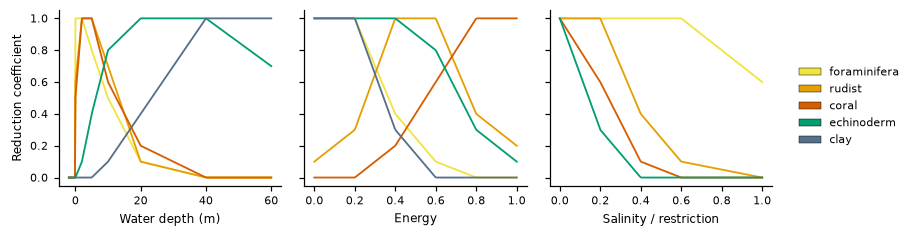

In [4]:
WD = np.array([-1e4, -0.01, 0.0, 2.0, 5.0, 10.0, 20.0, 40.0, 80.0, 1e4])  # water depth (m)
EN = np.array([-1.0, 0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 2.0])  # energy (0-1)
SA = np.array([-1.0, 0.0, 0.2, 0.4, 0.6, 1.0, 2.0])  # salinity / restriction (0-1)


def element(name, rate, water_depth, energy=None, salinity=None, production_factor=1.0):
    """Environment-optimum element; coefficients are given at the WD, EN, SA nodes."""
    curves = {"waterDepth": AccumulationCurve("waterDepth", WD, np.array(water_depth, dtype=float))}
    if energy is not None:
        curves["energy"] = AccumulationCurve("energy", EN, np.array(energy, dtype=float))
    if salinity is not None:
        curves["salinity"] = AccumulationCurve("salinity", SA, np.array(salinity, dtype=float))
    return AccumulationModelElementOptimum(name, rate * production_factor, curves)


def make_accumulation_model(production_factor=1.0):
    """Five-element carbonate factory; maximum rates are scaled by production_factor."""
    f = production_factor
    #                       water depth: -1e4 -0.01 0  2   5   10  20  40  80  1e4
    #                       energy:      -1   0   0.2 0.4 0.6 0.8 1   2
    #                       salinity:    -1   0   0.2 0.4 0.6 1   2
    return AccumulationModel(
        "Urgonian-type carbonate factory",
        {
            "foraminifera": element(
                "foraminifera", 24.0,
                [0, 0, 1, 1, 0.8, 0.5, 0.1, 0, 0, 0],
                [1, 1, 1, 0.4, 0.1, 0, 0, 0],
                [1, 1, 1, 1, 1, 0.6, 0.6],
                f,
            ),
            "rudist": element(
                "rudist", 48.0,
                [0, 0, 0.6, 1, 1, 0.7, 0.1, 0, 0, 0],
                [0.1, 0.1, 0.3, 1, 1, 0.4, 0.2, 0.2],
                [1, 1, 1, 0.4, 0.1, 0, 0],
                f,
            ),
            "coral": element(
                "coral", 60.0,
                [0, 0, 0.5, 1, 1, 0.6, 0.2, 0, 0, 0],
                [0, 0, 0, 0.2, 0.6, 1, 1, 1],
                [1, 1, 0.6, 0.1, 0, 0, 0],
                f,
            ),
            "echinoderm": element(
                "echinoderm", 30.0,
                [0, 0, 0, 0.1, 0.4, 0.8, 1, 1, 0.4, 0.2],
                [1, 1, 1, 1, 0.8, 0.3, 0.1, 0.1],
                [1, 1, 0.3, 0, 0, 0, 0],
                f,
            ),
            "clay": element(
                "clay", 12.0,
                [0, 0, 0, 0, 0, 0.1, 0.4, 1, 1, 1],
                [1, 1, 1, 0.3, 0, 0, 0, 0],
                None,
                f,
            ),
        },
    )


accumulation_model = make_accumulation_model()

fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.2), sharey=True)
for ax, (cond, nodes, label) in zip(
    axes, [("waterDepth", np.linspace(-2, 60, 400), "Water depth (m)"), ("energy", np.linspace(0, 1, 200), "Energy"), ("salinity", np.linspace(0, 1, 200), "Salinity / restriction")]
):
    for name in ELEMENTS:
        curve = accumulation_model.elements[name].getAccumulationCurve(cond)
        if curve is not None:
            ax.plot(nodes, [curve.getValueAt(v) for v in nodes], color=ELEMENT_COLORS[name], lw=1.2, label=name)
    ax.set_xlabel(label)
axes[0].set_ylabel("Reduction coefficient")
fig.tight_layout()
fig.legend(handles=element_legend_handles(), loc="center left", bbox_to_anchor=(1.0, 0.55), frameon=False)
save_figure(fig, "fig_step0_accumulation_laws")
plt.show()

**Figure 1 — Accumulation laws of the five elements**
(`fig_step0_accumulation_laws`).

*What it shows.* How each element reacts to the three environmental
conditions. The accumulation rate of an element is its maximum rate (table
above) multiplied by the product of its three reduction coefficients, so a
producer needs all three conditions to be favourable.

*Panels.*
- **(a) Water depth.** Reduction coefficient (0-1) against water depth (m).
  No element produces above sea level.
- **(b) Energy.** Coefficient against the energy index of the environment (0
  = quiet, 1 = high energy).
- **(c) Salinity / restriction.** Coefficient against the restriction index
  (0 = open marine, 1 = restricted).

*Observations.* Coral, rudist and foraminifera all produce at full rate
between 0 and 5 m (a), but they separate on energy (b): foraminifera produce
at low energy (≤ 0.2), rudists at moderate energy (0.4-0.6) and corals at
high energy (≥ 0.8). Only foraminifera tolerate restriction (c), whereas
corals and echinoderms need open-marine water. Echinoderms take over between
10 and 40 m and clay below 20 m (a).

*Interpretation.* Combined with the environment ranges of energy and
salinity, each environment selects one producer: lagoon → foraminifera,
back-reef → rudists, reef flat → corals, fore-reef → echinoderms, outer
platform → clay. Since lagoon, back-reef and reef flat share the same water
depths, the **composition of the deposits records the environment chosen by
the selector, not only the water depth**. This is what makes the environment
selector visible in the simulated logs.

### Scenario, well and simulation

* **Eustasy**: two superimposed sinusoids, a 1-Myr cycle of 10 m amplitude
  (20 m from highstand to lowstand, within the 15-30 m of Myr-scale
  Cretaceous sea-level changes; Miller et al., 2005; Haq, 2014) and a 100-kyr
  cycle of 2 m amplitude (4 m, a few metres as usual for greenhouse
  high-frequency cycles), over 3 Myr (126–123 Ma).
* **Well**: 8 m initial water depth, constant subsidence of 35 m/Myr.

The time step is adaptive: water-depth change and deposited thickness per step
are limited to 0.5 m, and the maximum step (10 kyr) resolves the 100-kyr cycle.

The environment selector uses the library defaults except the width of the
distality-trend kernel, set to $\sigma_T$ = 0.5 (the default, 2, is nearly flat
on distality ranks; see Step 2). This setting is used in all steps. The
simulation is stochastic; the seed (14) gives a realization close to the mean
thickness of the 50 realizations of Step 2.

In [5]:
# --- scenario ---
ages = np.arange(122.99, 126.0101, 0.0025)  # Ma
elapsed = 126.0 - ages
eustasy = 10.0 * np.sin(2 * np.pi * elapsed / 1.0) + 2.0 * np.sin(2 * np.pi * elapsed / 0.1)
eustatic_curve = Curve("Age", "Eustasy", ages, eustasy, "linear")
scenario = Scenario("Rimmed platform", accumulation_model, eustatic_curve, environment_model)

# --- realization (one well) ---
well = Well("W-mid", np.array([0.0, 0.0, 0.0]), 500.0)
well.addMarkers([Marker("Base", 500.0, 126.0), Marker("Top", 0.0, 123.0)])
subsidence = Curve("Age", "Subsidence rate", np.array([0.0, 200.0]), np.array([35.0, 35.0]))  # m/Myr
realization = RealizationData(well, 8.0, None, subsidence, SubsidenceType.RATE)

# --- simulation ---
DE_PARAMS = DESimulatorParameters(trend_sigma=0.5)  # environment selector settings
STEP0_SEED = 14
np.random.seed(STEP0_SEED)  # energy and salinity values are drawn from the global NumPy generator
simulator = FSSimulator(
    scenario,
    [realization],
    use_depositional_environment_simulator=True,
    deSimulator_params=DE_PARAMS,
    fsSimulator_params=FSSimulatorParameters(max_waterDepth_change_per_step=0.5, dt_max=0.01),
    seed=STEP0_SEED,
)
start = time.perf_counter()
simulator.prepare()
simulator.run()
simulator.finalize()
runtime_step0 = time.perf_counter() - start

ds0 = simulator.outputs
truth_well = simulator.simulatedWells[0]
print(f"{ds0.sizes['time']} time steps in {runtime_step0:.2f} s")
print(f"Total thickness: {float(ds0.thickness_cumul[0, -1]):.1f} m")
ds0

640 time steps in 1.16 s
Total thickness: 106.6 m


<xarray.Dataset> Size: 105kB
Dimensions:                 (time: 640, realization: 1)
Coordinates:
  * time                    (time) float64 5kB 126.0 126.0 126.0 ... 123.0 123.0
  * realization             (realization) int64 8B 0
Data variables: (12/17)
    sea_level               (time) float64 5kB 0.552 1.151 ... -1.492e-12
    dt                      (time) float64 5kB 0.002944 0.003279 ... 0.0002278
    initial_waterDepth      (realization) float64 8B 8.0
    subsidence              (realization, time) float64 5kB 0.103 ... 105.0
    basement                (realization, time) float64 5kB -8.103 ... -113.0
    accommodation           (realization, time) float64 5kB 0.6551 ... 105.0
    ...                      ...
    depo_rate_foraminifera  (realization, time) float64 5kB 4.743 ... 7.338
    depo_rate_rudist        (realization, time) float64 5kB 39.36 ... 34.64
    depo_rate_coral         (realization, time) float64 5kB 11.89 ... 4.518
    depo_rate_echinoderm    (realization, time) float64 5kB 13.25 ... 3.077
    depo_rate_clay          (realization, time) float64 5kB 0.1575 ... 0.1036
    environment             (realization, time) <U9 23kB 'ForeReef' ... 'Back...
Attributes:
    scenario_name:                   Rimmed platform
    start:                           126.0
    stop:                            123.0
    max_waterDepth_change_per_step:  0.5

Outputs come in two forms: an `xarray.Dataset` with all state variables per
realization and time step, and simulated `Well` objects carrying `MainElement`
(dominant element) and `Environment` logs in both depth and age domains.

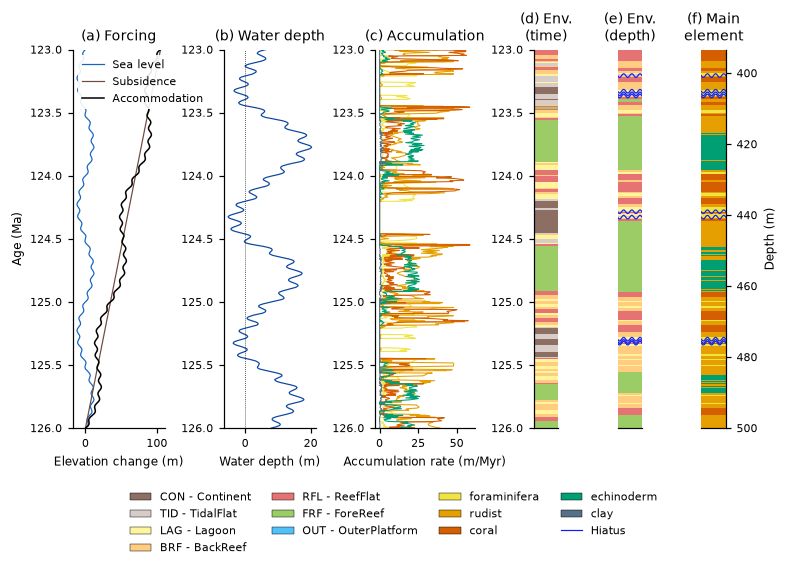

In [6]:
times = ds0.time.values
dts = ds0.dt.values
t_end = times - dts  # step-end ages
top_depth = 500.0 - float(ds0.thickness_cumul[0, -1])

fig, axes = plt.subplots(1, 6, figsize=(7.2, 4.4), gridspec_kw={"width_ratios": [1.2, 1.2, 1.3, 0.32, 0.32, 0.32]})
ax = axes[0]
ax.plot(ds0.sea_level.values, t_end, color="#1565c0", lw=0.8, label="Sea level")
ax.plot(ds0.subsidence[0].values, t_end, color="#6d4c41", lw=0.8, label="Subsidence")
ax.plot(ds0.accommodation[0].values, t_end, color="k", lw=1.0, label="Accommodation")
ax.set_xlabel("Elevation change (m)")
ax.set_ylabel("Age (Ma)")
ax.set_title("(a) Forcing")
ax.legend(loc="upper left", frameon=True, framealpha=0.9, edgecolor="none")

ax = axes[1]
ax.plot(ds0.waterDepth[0].values, times, color="#0d47a1", lw=0.8)
ax.axvline(0, color="k", lw=0.5, ls=":")
ax.set_xlabel("Water depth (m)")
ax.set_title("(b) Water depth")

ax = axes[2]
for name in ELEMENTS:
    ax.plot(ds0[f"depo_rate_{name}"][0].values, times, color=ELEMENT_COLORS[name], lw=0.7, label=name)
ax.set_xlabel("Accumulation rate (m/Myr)")
ax.set_title("(c) Accumulation")

ax = axes[3]
plot_time_column(ax, times, dts, ds0.environment[0].values)
ax.set_title("(d) Env.\n(time)")
for ax in axes[:4]:
    ax.set_ylim(126.0, 123.0)

for ax, log_name, title in [(axes[4], "Environment", "(e) Env.\n(depth)"), (axes[5], "MainElement", "(f) Main\nelement")]:
    plot_depth_column(ax, truth_well.getDepthLog(log_name))
    draw_hiatus(ax, hiatus_depths(truth_well))
    ax.set_ylim(500.0, top_depth)
    ax.set_title(title)
for ax in axes[3:]:
    ax.set_xlim(0, 1)
    ax.set_xticks([])
axes[4].set_yticks([])
axes[4].spines["left"].set_visible(False)
ax = axes[5]
ax.set_ylabel("Depth (m)")
ax.yaxis.set_label_position("right")
ax.yaxis.tick_right()
ax.spines["right"].set_visible(True)
ax.spines["left"].set_visible(False)
fig.tight_layout()
fig.legend(
    handles=env_legend_handles(ENVIRONMENTS[:7]) + element_legend_handles() + [hiatus_legend_handle()],
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.0),
)
save_figure(fig, "fig_step0_minimal_run")
plt.show()

**Figure 2 — Minimal run: one well, one scenario** (`fig_step0_minimal_run`).

*What it shows.* The main outputs of a single simulation and how they are
linked: forcing → water depth → environment → producers → deposits.

*Panels.*
- **(a) Forcing.** Sea level (eustasy), cumulative subsidence and
  accommodation (their sum) since 126 Ma, against age.
- **(b) Water depth** at the depositional surface. The dotted line is sea
  level: negative values mean exposure.
- **(c) Accumulation rate** of each element (m/Myr).
- **(d) Environment in time.** Environment selected at each step, against
  age.
- **(e) Environment in depth.** Environment log of the simulated well,
  against depth. Blue wavy lines are hiatuses (steps without deposition).
- **(f) Main element** log in depth (the element with the highest rate at
  each step), i.e. what a geologist would describe in a core.

*Observations.* Accommodation (a) grows by 105 m (35 m/Myr subsidence over 3
Myr), with ±12 m eustatic oscillations. Water depth (b) oscillates between -5
and 20 m with the 1-Myr cycle. At each lowstand (≈ 125.3, 124.4 and 123.3 Ma)
the platform is exposed (continent in d) and accumulation stops (c). During
the rises the platform-top environments (lagoon, back-reef, reef flat)
alternate with high rudist and coral rates (up to 48 and 59 m/Myr). At the
highstands (≈ 125.75, 124.75 and 123.75 Ma) the well deepens into fore-reef
conditions where echinoderms dominate at about 20 m/Myr. Hiatuses add up to
0.62 Myr (21% of the time) but no thickness: the 3 Myr are recorded in 106.6
m of rock (e), where the fore-reef takes 43% of the thickness for 29% of the
time, and the main-element log (f) is dominated by rudists (46%), then corals
and echinoderms (21% each) and foraminifera (12%).

*Interpretation.* The platform keeps up with accommodation on average, but
each 1-Myr cycle is recorded as an exposure surface, a shallow-water
carbonate succession built during the rise and a deeper fore-reef interval at
the highstand, when the sea-level rise outpaces production. The comparison of
(d) and (e) shows why stratigraphic thickness is not time: productive
environments are expanded and exposure is reduced to a surface. The
composition log (f) follows the environment log (e) because each environment
selects its producers (Figure 1).

### Parameterized builders

The following functions rebuild exactly the Step 0 model but expose the
parameters varied in the next steps. The check at the end of the cell verifies
that they reproduce Step 0 bit for bit (same seed, same outputs).

In [7]:
T_START, T_END, BASE_DEPTH = 126.0, 123.0, 500.0
FS_PARAMS = FSSimulatorParameters(max_waterDepth_change_per_step=0.5, dt_max=0.01)


def make_eustatic_curve(amplitude_3rd=10.0, period_3rd=1.0, amplitude_4th=2.0, period_4th=0.1):
    """Two-frequency sinusoidal eustatic curve (m) sampled every 2.5 kyr."""
    a = np.arange(T_END - 0.01, T_START + 0.0101, 0.0025)
    e = T_START - a
    values = amplitude_3rd * np.sin(2 * np.pi * e / period_3rd) + amplitude_4th * np.sin(2 * np.pi * e / period_4th)
    return Curve("Age", "Eustasy", a, values, "linear")


def make_scenario(amplitude_3rd=10.0, production_factor=1.0, eustatic_curve=None):
    curve = make_eustatic_curve(amplitude_3rd) if eustatic_curve is None else eustatic_curve
    return Scenario("Rimmed platform", make_accumulation_model(production_factor), curve, environment_model)


def make_realization(name, initial_water_depth, subsidence_rate, initial_environment=None):
    w = Well(name, np.array([0.0, 0.0, 0.0]), BASE_DEPTH)
    w.addMarkers([Marker("Base", BASE_DEPTH, T_START), Marker("Top", 0.0, T_END)])
    subs = Curve("Age", "Subsidence rate", np.array([0.0, 200.0]), np.array([subsidence_rate, subsidence_rate]))
    return RealizationData(w, initial_water_depth, initial_environment, subs, SubsidenceType.RATE)


def run_simulation(scenario, realizations, seed, de_params=DE_PARAMS, use_de=True, fs_params=FS_PARAMS):
    """Build, run and finalize a simulator. Returns (simulator, runtime in s)."""
    np.random.seed(seed)
    sim = FSSimulator(
        scenario,
        realizations,
        use_depositional_environment_simulator=use_de,
        deSimulator_params=de_params,
        fsSimulator_params=fs_params,
        seed=seed,
    )
    t0 = time.perf_counter()
    sim.prepare()
    sim.run()
    sim.finalize()
    return sim, time.perf_counter() - t0


check, _ = run_simulation(make_scenario(), [make_realization("W-mid", 8.0, 35.0)], seed=STEP0_SEED)
assert np.array_equal(check.outputs.environment.values, ds0.environment.values)
assert np.allclose(check.outputs.thickness_cumul.values, ds0.thickness_cumul.values)
print("Builders reproduce Step 0 exactly.")

Builders reproduce Step 0 exactly.


## Step 1 — Verification against an analytical solution

With a single element whose production decreases linearly with water depth,
$P(w) = P_{max}(1 - w/w_d)$ for $0 \le w \le w_d$ (no production above sea
level nor below $w_d$), a constant subsidence rate $S$ and no eustasy, water
depth obeys

$$\frac{dw}{dt} = S - P(w) \quad\Rightarrow\quad w(t) = w^* + (w_0 - w^*)\,e^{kt},
\qquad w^* = w_d\left(1 - \frac{S}{P_{max}}\right),\; k = \frac{P_{max}}{w_d}.$$

The equilibrium depth $w^*$ is unstable, which is the drowning threshold of
carbonate platforms (Schlager, 1981):

* if $w_0 < w^*$, production exceeds subsidence, the platform shallows up to
  sea level and then keeps up ($w \approx 0$, accumulation rate $= S$);
* if $w_0 > w^*$, the platform deepens at an accelerating rate until
  production stops at $w_d$, then water depth increases at rate $S$ (drowning).

Both cases are run with a decreasing water-depth tolerance per step
(`max_waterDepth_change_per_step`) to measure the convergence of the explicit
adaptive scheme.

In [8]:
P_MAX, W_D, S_VERIF, DURATION = 60.0, 30.0, 40.0, 1.0  # m/Myr, m, m/Myr, Myr
K_VERIF = P_MAX / W_D
W_STAR = W_D * (1.0 - S_VERIF / P_MAX)  # 10 m


def analytical_water_depth(t, w0):
    """Exact water depth after t Myr for an initial water depth w0."""
    w = W_STAR + (w0 - W_STAR) * np.exp(K_VERIF * t)
    if w0 < W_STAR:  # catch-up then keep-up at sea level
        return np.maximum(w, 0.0)
    t_drown = np.log((W_D - W_STAR) / (w0 - W_STAR)) / K_VERIF
    return np.where(t > t_drown, W_D + S_VERIF * (t - t_drown), w)


def linear_production_scenario():
    curve = AccumulationCurve(
        "waterDepth", np.array([-1e4, -1e-3, 0.0, W_D, 1e4]), np.array([0.0, 0.0, 1.0, 0.0, 0.0])
    )
    model = AccumulationModel("linear", {"A": AccumulationModelElementOptimum("A", P_MAX, {"waterDepth": curve})})
    return Scenario("Analytical", model, None)


def verification_realization(w0):
    w = Well("V", np.zeros(3), BASE_DEPTH)
    w.addMarkers([Marker("Base", BASE_DEPTH, DURATION), Marker("Top", 0.0, 0.0)])
    subs = Curve("Age", "Subsidence rate", np.array([-1.0, 10.0]), np.array([S_VERIF, S_VERIF]))
    return RealizationData(w, w0, None, subs, SubsidenceType.RATE)


tolerances = [2.0, 1.0, 0.5, 0.25, 0.125, 0.0625]
cases = {"Keep-up ($w_0$ = 4 m)": 4.0, "Drowning ($w_0$ = 14 m)": 14.0}
verification_rows, verification_runs = [], {}
for case, w0 in cases.items():
    for tol in tolerances:
        params = FSSimulatorParameters(max_waterDepth_change_per_step=tol, dt_min=1e-7, dt_max=1.0)
        sim, runtime = run_simulation(
            linear_production_scenario(), [verification_realization(w0)], seed=0, use_de=False, fs_params=params
        )
        ds = sim.outputs
        elapsed_t = DURATION - ds.time.values
        error = np.abs(ds.waterDepth[0].values - analytical_water_depth(elapsed_t, w0))
        verification_rows.append(
            {"case": case, "tolerance_m": tol, "n_steps": ds.sizes["time"], "max_error_m": error.max(), "runtime_s": runtime}
        )
        verification_runs[(case, tol)] = ds
verification = pd.DataFrame(verification_rows)
verification.to_csv(os.path.join(OUTPUT_DIR, "table_step1_verification.csv"), index=False)

# observed convergence order from a log-log fit
for case in cases:
    sub = verification[verification.case == case]
    order = np.polyfit(np.log(sub.tolerance_m), np.log(sub.max_error_m), 1)[0]
    print(f"{case}: convergence order = {order:.2f}, max error / tolerance <= {(sub.max_error_m / sub.tolerance_m).max():.2f}")
verification

Keep-up ($w_0$ = 4 m): convergence order = 1.11, max error / tolerance <= 0.85
Drowning ($w_0$ = 14 m): convergence order = 1.00, max error / tolerance <= 1.07


,case,tolerance_m,n_steps,max_error_m,runtime_s
0,Keep-up ($w_0$ = 4 m),2.0000,61,0.867139,0.089052
1,Keep-up ($w_0$ = 4 m),1.0000,130,0.728092,0.097106
2,Keep-up ($w_0$ = 4 m),0.5000,295,0.303749,0.253761
3,Keep-up ($w_0$ = 4 m),0.2500,338,0.195837,0.199781
4,Keep-up ($w_0$ = 4 m),0.1250,821,0.106761,0.713804
5,Keep-up ($w_0$ = 4 m),0.0625,1844,0.013536,1.444665
6,Drowning ($w_0$ = 14 m),2.0000,23,2.116307,0.012335
7,Drowning ($w_0$ = 14 m),1.0000,39,1.069460,0.022297
8,Drowning ($w_0$ = 14 m),0.5000,72,0.535758,0.046199
9,Drowning ($w_0$ = 14 m),0.2500,139,0.267962,0.096311


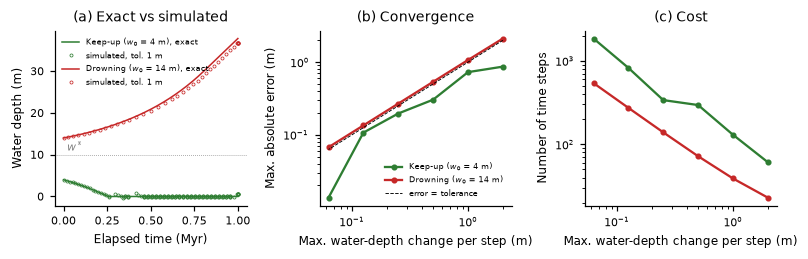

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(7.2, 2.4))
colors = dict(zip(cases, ["#2e7d32", "#c62828"]))
t_fine = np.linspace(0, DURATION, 500)
for case, w0 in cases.items():
    ax = axes[0]
    ax.plot(t_fine, analytical_water_depth(t_fine, w0), color=colors[case], lw=1.0, label=f"{case}, exact")
    ds = verification_runs[(case, 1.0)]
    ax.plot(DURATION - ds.time.values, ds.waterDepth[0].values, "o", ms=2.0, mfc="none", mew=0.5, color=colors[case], label="simulated, tol. 1 m")
    sub = verification[verification.case == case]
    axes[1].loglog(sub.tolerance_m, sub.max_error_m, "o-", color=colors[case], ms=3, label=case)
    axes[2].loglog(sub.tolerance_m, sub.n_steps, "o-", color=colors[case], ms=3, label=case)
axes[0].axhline(W_STAR, color="grey", lw=0.5, ls=":")
axes[0].text(0.02, W_STAR + 1, "$w^*$", fontsize=7, color="grey")
axes[0].set_xlabel("Elapsed time (Myr)")
axes[0].set_ylabel("Water depth (m)")
axes[0].set_title("(a) Exact vs simulated")
axes[0].legend(frameon=False, fontsize=5.5)
ref = np.array(tolerances)
axes[1].loglog(ref, ref, "k--", lw=0.6, label="error = tolerance")
axes[1].set_xlabel("Max. water-depth change per step (m)")
axes[1].set_ylabel("Max. absolute error (m)")
axes[1].set_title("(b) Convergence")
axes[1].legend(frameon=False, fontsize=5.5)
axes[2].set_xlabel("Max. water-depth change per step (m)")
axes[2].set_ylabel("Number of time steps")
axes[2].set_title("(c) Cost")
fig.tight_layout()
save_figure(fig, "fig_step1_verification")
plt.show()

**Figure 3 — Verification against the analytical solution**
(`fig_step1_verification`).

*What it shows.* That the code solves the stated equations, and how the
accuracy and the cost depend on the time-step tolerance (maximum water-depth
change per step).

*Panels.*
- **(a) Exact vs simulated.** Water depth against elapsed time for the two
  regimes: exact solution (lines) and simulation with a 1 m tolerance
  (circles). The dotted line is the unstable equilibrium depth $w^*$ = 10 m.
- **(b) Convergence.** Maximum absolute error against the tolerance
  (log-log). The dashed line is error = tolerance.
- **(c) Cost.** Number of time steps against the tolerance.

*Observations.* Starting below $w^*$ (4 m), the platform shallows to sea
level in about 0.25 Myr and then keeps up; starting above $w^*$ (14 m), it
deepens at an accelerating rate and drowns (a). The simulated points follow
the exact curves. The error decreases linearly with the tolerance (b): the
convergence order is 1.11 (keep-up) and 1.00 (drowning), and the error stays
below the tolerance (ratio ≤ 0.85 and ≤ 1.07). The number of steps is
inversely proportional to the tolerance (c), from 23-61 steps at 2 m to
540-1844 steps at 0.06 m. The keep-up case needs more steps because
production switches on and off around sea level.

*Interpretation.* The adaptive explicit scheme is first-order accurate and
its error is controlled by the tolerance, as expected. The tolerance is
therefore a resolution choice: it should be smaller than the thinnest bed or
the smallest water-depth change one wants to resolve. The default 0.5 m used
in this study gives errors of about 0.3-0.5 m at a small cost.

## Step 2 — Stochastic behaviour of the environment selector

The environment at each step is sampled from a posterior combining a prior with
three likelihoods: water depth $P(D|e)$, transition from the previous
environment $P(S|e)$ (Walther's law) and distality trend $P(T|e)$. Here the
Step 0 well is simulated 50 times for three configurations, switching the
likelihoods on one at a time (a weight of 0 makes a likelihood uniform). The
kernel widths are $\sigma_D$ = 2 m (water depth), $\sigma_S$ = 1 (transition,
water-depth gap in metres plus distality rank difference) and $\sigma_T$ = 0.5
(trend). The trend likelihood compares distality *ranks* (consecutive
environments differ by 1), so the library default $\sigma_T$ = 2 is almost
flat; $\sigma_T$ = 0.5 is used throughout. The sensitivity to the three
widths is shown in the supplementary section below.

Statistics are computed on two logs of each simulated well: the
**environment** log (the interpretation) and the **main element** log (the
composition, i.e. what a geologist describes in a core). For each log we
compute the number of beds, the pooled embedded transition matrix
(self-transitions removed) and a chi-square test of the Markov property against
quasi-independence (Powers & Easterling, 1982). Total thickness is also
compared, since the environment controls production.

In [10]:
N_REAL = 50
SIGMA_REF = {name: getattr(DE_PARAMS, name) for name in ("waterDepth_sigma", "transition_sigma", "trend_sigma")}
configurations = {
    "Water depth": DESimulatorParameters(**SIGMA_REF, transition_weight=0.0, trend_weight=0.0),
    "+ Transition": DESimulatorParameters(**SIGMA_REF, trend_weight=0.0),
    "+ Trend": DESimulatorParameters(**SIGMA_REF),
}
REF_CONFIG = "+ Trend"


def run_selector_configuration(label, de_params, n_real=N_REAL, seed=2):
    """Simulate the Step 0 well n_real times and compute log statistics."""
    sim, runtime = run_simulation(
        make_scenario(), [make_realization(f"R{i}", 8.0, 35.0) for i in range(n_real)], seed=seed, de_params=de_params
    )
    result = {"sim": sim, "runtime": runtime}
    row = {"configuration": label, "runtime_s": runtime}
    for log_name, states_all in [("Environment", ENVIRONMENTS), ("MainElement", ELEMENTS)]:
        sequences, props = [], []
        for w in sim.simulatedWells:
            labels, thicknesses = striplogToSequence(w.getDepthLog(log_name))
            sequences.append(labels)
            props.append(thicknessProportions(labels, thicknesses))
        states = [s for s in states_all if any(s in seq for seq in sequences)]
        counts, _ = pooledTransitionCountMatrix(sequences, states=states)
        test = embeddedMarkovChiSquareTest(counts)
        result[log_name] = {"counts": counts, "states": states, "test": test}
        key = "env" if log_name == "Environment" else "elem"
        row[f"{key}_beds_per_well"] = np.mean([len(s) for s in sequences])
        row[f"{key}_chi2"] = test.statistic
        row[f"{key}_dof"] = test.dof
        row[f"{key}_p_value"] = test.pValue
        mean_props = pd.DataFrame(props).fillna(0).mean()
        row.update({f"{key}_prop_{k}": v for k, v in mean_props.items()})
    thick = sim.outputs.thickness_cumul[:, -1].values
    row["thickness_mean_m"] = thick.mean()
    row["thickness_std_m"] = thick.std(ddof=1)
    result["row"] = row
    return result, row


ablation, ablation_rows = {}, []
for label, de_params in configurations.items():
    ablation[label], row = run_selector_configuration(label, de_params)
    ablation_rows.append(row)
ablation_table = pd.DataFrame(ablation_rows).set_index("configuration")
ablation_table.to_csv(os.path.join(OUTPUT_DIR, "table_step2_ablation.csv"))
summary_cols = [
    "env_beds_per_well", "env_chi2", "elem_beds_per_well", "elem_chi2", "thickness_mean_m", "thickness_std_m", "runtime_s",
]
ablation_table[summary_cols].round(1)

,env_beds_per_well,env_chi2,elem_beds_per_well,elem_chi2,thickness_mean_m,thickness_std_m,runtime_s
configuration,,,,,,,
Water depth,392.2,1196.3,360.7,2148.6,105.9,0.4,24.0
+ Transition,205.6,4289.8,229.7,567.0,105.4,1.1,26.9
+ Trend,111.6,3263.1,135.2,454.1,105.2,1.1,26.2


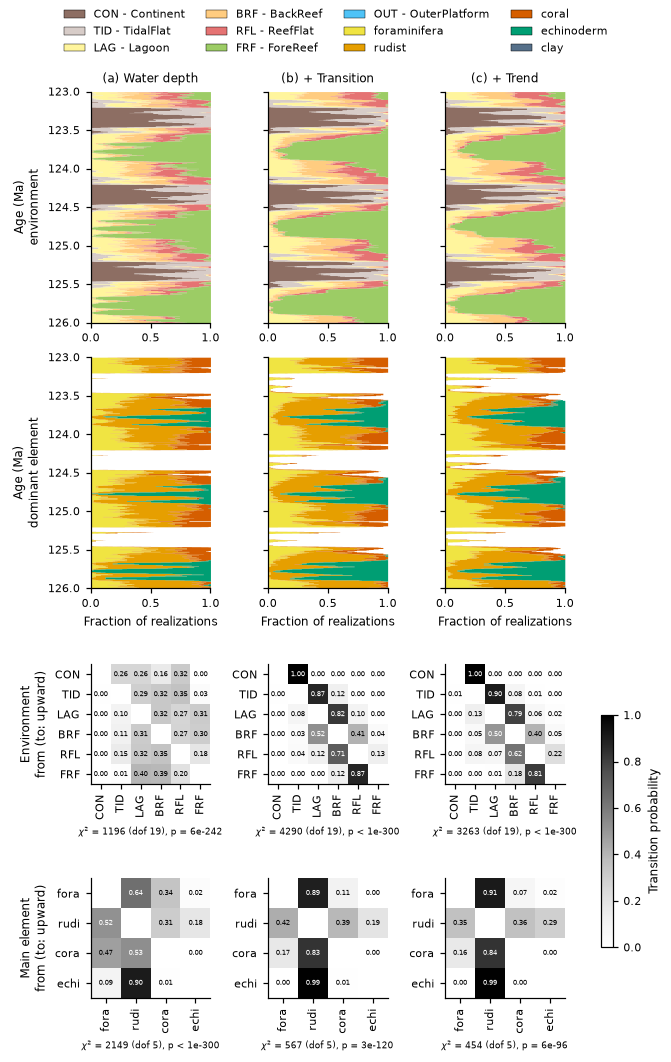

In [11]:
def dominant_element(ds):
    """Dominant element at each step (realization, time) from element rates."""
    rates = np.stack([ds[f"depo_rate_{e}"].values for e in ELEMENTS], axis=-1)
    dominant = np.array(ELEMENTS, dtype=object)[np.argmax(rates, axis=-1)]
    dominant[rates.max(axis=-1) <= 0] = "none"
    return dominant


def stacked_fractions(ax, t, states_by_real, states):
    left = np.zeros_like(t)
    for name in states:
        frac = (states_by_real == name).mean(axis=0)
        if frac.max() == 0:
            continue
        ax.fill_betweenx(t, left, left + frac, step="post", color=COLORS[name], lw=0)
        left = left + frac
    ax.set_ylim(T_START, T_END)
    ax.set_xlim(0, 1)


def transition_matrix_plot(ax, res, short=None):
    probs = transitionProbabilityMatrix(res["counts"])
    im = ax.imshow(probs, vmin=0, vmax=1, cmap="Greys")
    ticks = [short[s] if short else s[:4] for s in res["states"]]
    ax.set_xticks(range(len(ticks)), ticks, rotation=90)
    ax.set_yticks(range(len(ticks)), ticks)
    for (r, c), v in np.ndenumerate(probs):
        if np.isfinite(v) and r != c:
            ax.text(c, r, f"{v:.2f}", ha="center", va="center", fontsize=4.5, color="w" if v > 0.5 else "k")
    test = res["test"]
    p_txt = f"p = {test.pValue:.0e}" if test.pValue > 1e-300 else "p < 1e-300"
    ax.set_xlabel(f"$\\chi^2$ = {test.statistic:.0f} (dof {test.dof}), {p_txt}", fontsize=6)
    return im


fig, axes = plt.subplots(
    4, len(ablation), figsize=(6.0, 9.6), gridspec_kw={"height_ratios": [1.2, 1.2, 0.9, 0.9]}, layout="constrained"
)
letters = iter("abcdefghijklmnop")
for j, (label, res) in enumerate(ablation.items()):
    ds = res["sim"].outputs
    t = ds.time.values
    ax = axes[0, j]
    stacked_fractions(ax, t, ds.environment.values, ENVIRONMENTS)
    ax.set_title(f"({next(letters)}) {label}", fontsize=8)
    ax = axes[1, j]
    stacked_fractions(ax, t, dominant_element(ds), ELEMENTS)
    axes[1, j].set_xlabel("Fraction of realizations")
    im = transition_matrix_plot(axes[2, j], res["Environment"], ENV_SHORT)
    transition_matrix_plot(axes[3, j], res["MainElement"])
    if j > 0:
        for i in range(2):
            axes[i, j].set_yticklabels([])
axes[0, 0].set_ylabel("Age (Ma)\nenvironment")
axes[1, 0].set_ylabel("Age (Ma)\ndominant element")
axes[2, 0].set_ylabel("Environment\nfrom (to: upward)")
axes[3, 0].set_ylabel("Main element\nfrom (to: upward)")
fig.colorbar(im, ax=axes[2:, :], shrink=0.6, label="Transition probability")
fig.legend(
    handles=env_legend_handles(ENVIRONMENTS[:7]) + element_legend_handles(),
    loc="outside upper center",
    ncol=4,
    frameon=False,
)
save_figure(fig, "fig_step2_stochastic_ablation")
plt.show()

**Figure 4 — Effect of the three likelihoods of the environment selector**
(`fig_step2_stochastic_ablation`).

*What it shows.* What each likelihood of the environment selector adds, by
switching them on one at a time on the same well simulated 50 times: (column
a) water depth only, (column b) + transition, (column c) + distality trend.

*Panels (one column per configuration).*
- **Row 1 — Environment in time.** For each time step, fraction of the 50
  realizations in each environment (stacked).
- **Row 2 — Dominant element in time.** Same for the dominant producer. White
  gaps are steps without production (exposure).
- **Row 3 — Environment transition matrix.** Pooled embedded transitions
  upward (row = environment below, column = environment above;
  self-transitions removed). The chi-square test of the Markov property
  against quasi-independence is given below the matrix.
- **Row 4 — Main-element transition matrix**, same for the composition log.

*Observations.* The 1-Myr cycles (exposure → platform top → fore-reef) appear
in all configurations, since they are imposed by water depth (rows 1-2). With
water depth only (a), lagoon, back-reef, reef flat and fore-reef are mixed at
all times, every environment can follow any other (row 3: probabilities of
0.2-0.4 between lagoon, back-reef, reef flat and fore-reef) and the wells
contain about 390 environment beds. Adding the transition likelihood (b)
organises the successions along the platform profile: continent → tidal flat
(1.00), tidal flat → lagoon (0.87), lagoon → back-reef (0.82) and fore-reef →
reef flat (0.87), and halves the number of beds (about 210). In the
composition log (row 4), coral is then overlain by rudist in 83% of the cases
instead of 53%. Adding the trend likelihood (c) halves the number of beds
again (about 110): environment intervals are more persistent and less mixed
between realizations in row 1. All chi-square tests reject random ordering
($p$ < 1e-90).

*Interpretation.* Water depth alone cannot discriminate environments that
share the same depth range, so it produces a random alternation of facies.
The transition likelihood imposes Walther's law (only neighbouring
environments follow each other) and the trend likelihood makes transgressive
and regressive trends persist over several steps. The selector thus controls
the internal organisation and the bed thickness of each cycle, not the cycles
themselves. Total thickness hardly changes between configurations (105 ± 1 m)
because the platform keeps up with accommodation. The chi-square statistic is
highest for the composition log with water depth alone (rapid two-state
alternations), so it measures non-randomness, not geological realism.

### Supplementary — sensitivity of the selector to the kernel widths

Each kernel width is halved and doubled around the reference configuration
of Step 2 (all likelihoods on, $\sigma_D$ = 2 m, $\sigma_S$ = 1,
$\sigma_T$ = 0.5), one at a time, with the same 50 realizations and seed. The
reference column reuses the Step 2 run.

In [12]:
SIGMA_LABELS = {
    "waterDepth_sigma": ("$\\sigma_D$", "water depth", " m"),
    "transition_sigma": ("$\\sigma_S$", "transition", ""),
    "trend_sigma": ("$\\sigma_T$", "trend", ""),
}
SIGMA_FACTORS = [0.5, 1.0, 2.0]
sensitivity, sensitivity_rows = {}, []
for name, ref_value in SIGMA_REF.items():
    for factor in SIGMA_FACTORS:
        value = ref_value * factor
        if factor == 1.0:
            res = ablation[REF_CONFIG]
            row = dict(res["row"])
        else:
            params = DESimulatorParameters(**{**SIGMA_REF, name: value})
            res, row = run_selector_configuration(f"{name} = {value:g}", params)
        row.update({"parameter": name, "factor": factor, "sigma": value})
        sensitivity[(name, factor)] = res
        sensitivity_rows.append(row)
sensitivity_table = pd.DataFrame(sensitivity_rows).set_index(["parameter", "factor"])
sensitivity_table.to_csv(os.path.join(OUTPUT_DIR, "table_S1_selector_sensitivity.csv"))
sensitivity_table[["sigma", "env_beds_per_well", "elem_beds_per_well", "thickness_mean_m", "thickness_std_m"]].round(2)

sigma  env_beds_per_well  elem_beds_per_well  \
parameter        factor                                                 
waterDepth_sigma 0.5      1.00              92.92              125.96   
                 1.0      2.00             111.62              135.20   
                 2.0      4.00             139.84              153.14   
transition_sigma 0.5      0.50              25.04               48.26   
                 1.0      1.00             111.62              135.20   
                 2.0      2.00             155.88              173.98   
trend_sigma      0.5      0.25              90.90              115.04   
                 1.0      0.50             111.62              135.20   
                 2.0      1.00             156.10              179.34   

                         thickness_mean_m  thickness_std_m  
parameter        factor                                     
waterDepth_sigma 0.5               105.57             1.04  
                 1.0               105.24             1.14  
                 2.0               104.71             1.50  
transition_sigma 0.5                99.29             1.97  
                 1.0               105.24             1.14  
                 2.0               105.54             0.81  
trend_sigma      0.5               105.12             1.34  
                 1.0               105.24             1.14  
                 2.0               105.20             1.25

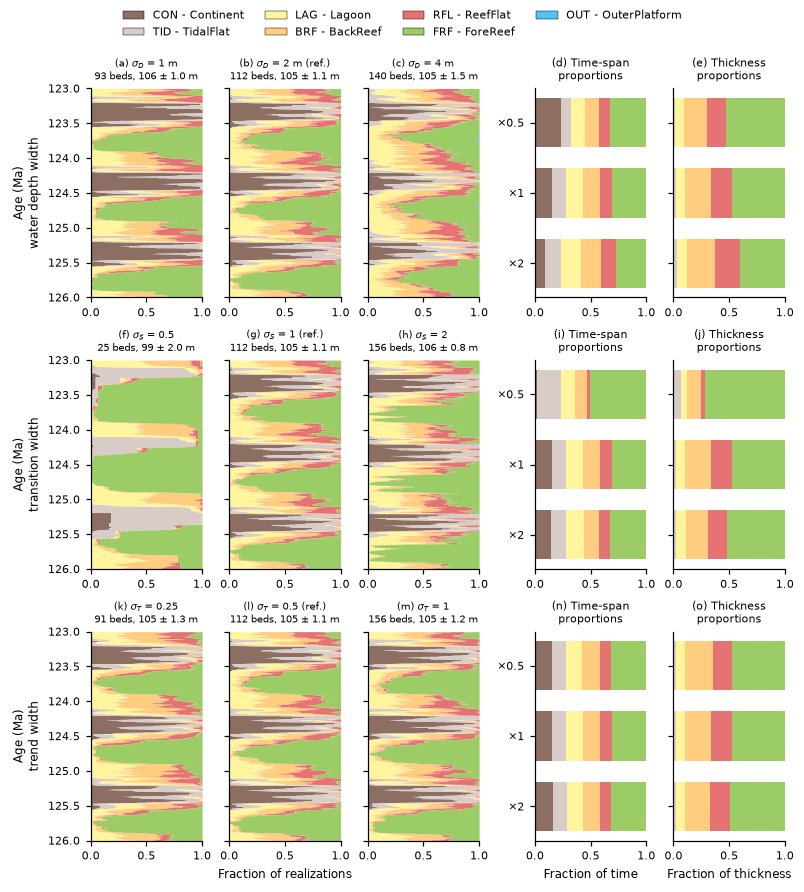

In [13]:
def time_span_proportions(ds):
    """Mean time-span proportion of each environment over the realizations."""
    dt = ds.dt.values
    envs = ds.environment.values
    return {env: float(((envs == env) * dt).sum(axis=1).mean() / dt.sum()) for env in ENVIRONMENTS}


def proportion_bars(ax, proportions, title, xlabel, last_row, ylabels=True):
    """Stacked horizontal bars of environment proportions, one bar per width factor."""
    for k, props in enumerate(proportions):
        left = 0.0
        for env in ENVIRONMENTS:
            v = props.get(env, 0.0)
            if v > 0:
                ax.barh(k, v, left=left, color=COLORS[env], height=0.7, lw=0)
                left += v
    ax.set_yticks(range(len(SIGMA_FACTORS)), [f"×{f:g}" for f in SIGMA_FACTORS] if ylabels else [])
    ax.invert_yaxis()
    ax.set_xlim(0, 1)
    ax.set_title(title, fontsize=7)
    if last_row:
        ax.set_xlabel(xlabel)


fig, axes = plt.subplots(
    len(SIGMA_REF), len(SIGMA_FACTORS) + 2, figsize=(7.2, 8.0),
    gridspec_kw={"width_ratios": [1, 1, 1, 1, 1]}, layout="constrained",
)
letters = iter("abcdefghijklmnop")
for i, name in enumerate(SIGMA_REF):
    symbol, long_name, unit = SIGMA_LABELS[name]
    last_row = i == len(SIGMA_REF) - 1
    for j, factor in enumerate(SIGMA_FACTORS):
        res = sensitivity[(name, factor)]
        row = res["row"]
        ds = res["sim"].outputs
        ax = axes[i, j]
        stacked_fractions(ax, ds.time.values, ds.environment.values, ENVIRONMENTS)
        ref_tag = " (ref.)" if factor == 1.0 else ""
        ax.set_title(
            f"({next(letters)}) {symbol} = {SIGMA_REF[name] * factor:g}{unit}{ref_tag}\n"
            f"{row['env_beds_per_well']:.0f} beds, {row['thickness_mean_m']:.0f} ± {row['thickness_std_m']:.1f} m",
            fontsize=6.5,
        )
        if j > 0:
            ax.set_yticklabels([])
        if last_row and j == 1:
            ax.set_xlabel("Fraction of realizations")
    axes[i, 0].set_ylabel(f"Age (Ma)\n{long_name} width")
    # mean time-span and thickness proportions of environments for the three widths
    proportion_bars(
        axes[i, -2],
        [time_span_proportions(sensitivity[(name, f)]["sim"].outputs) for f in SIGMA_FACTORS],
        f"({next(letters)}) Time-span\nproportions",
        "Fraction of time",
        last_row,
    )
    proportion_bars(
        axes[i, -1],
        [{env: sensitivity[(name, f)]["row"].get(f"env_prop_{env}", 0.0) for env in ENVIRONMENTS} for f in SIGMA_FACTORS],
        f"({next(letters)}) Thickness\nproportions",
        "Fraction of thickness",
        last_row,
        ylabels=False,
    )
fig.legend(handles=env_legend_handles(ENVIRONMENTS[:7]), loc="outside upper center", ncol=4, frameon=False)
save_figure(fig, "fig_S1_selector_sensitivity")
plt.show()

**Figure S1 — Sensitivity of the environment selector to the kernel widths**
(`fig_S1_selector_sensitivity`, supplementary material).

*What it shows.* How the width of each likelihood kernel changes the
simulated successions, by halving and doubling one width at a time around the
reference of Figure 4c (middle column of each row).

*Panels.*
- **Rows.** Water-depth width $\sigma_D$ (1, 2, 4 m), transition width
  $\sigma_S$ (0.5, 1, 2) and trend width $\sigma_T$ (0.25, 0.5, 1).
- **Columns 1-3.** Fraction of the 50 realizations in each environment
  against age, for half, reference and twice the width. The title gives the
  mean number of environment beds per well and the thickness (mean ± standard
  deviation).
- **Column 4.** Time-span proportion of each environment for the three
  widths: fraction of the simulated duration (3 Myr) spent in it,
  including exposure and non-deposition, averaged over the 50
  realizations.
- **Column 5.** Thickness proportion of each environment for the three
  widths: fraction of the well thickness, computed on the depth log of
  each well and averaged over the 50 realizations.

*Observations.* A narrow water-depth kernel (a) gives fewer beds (93) and
more fore-reef; a wide one (c) gives more beds (140) and lets platform-top
environments persist into deeper water (fore-reef 41% instead of 47%, e). The
transition width is the most sensitive: with $\sigma_S$ = 0.5 (f)
environments lock in (25 beds per well), the tidal flat persists for long
periods after exposure, the fore-reef takes 72% of the thickness (j) and the
wells are thinner (99 m instead of 105 m); with $\sigma_S$ = 2 (h) beds are
more numerous (156) and proportions stay close to the reference. The trend
width (k-o) mainly changes the number of beds (91, 112 and 156), with almost
identical proportions and thickness.

The time-span proportions (d, i, n) differ from the thickness proportions
(e, j, o) because environments accumulate at different rates. In the
reference, the continent occupies 16% of the time but leaves no thickness
(exposure), and the tidal flat and lagoon occupy 13% and 15% of the time
but only 2% and 8% of the thickness; conversely, the back-reef (15% of
the time, 23% of the thickness), reef flat (10%, 19%) and fore-reef (31%,
47%) are over-represented in the wells. The water-depth width changes the
time spent on the continent (23%, 16% and 9% for $\sigma_D$ = 1, 2 and
4 m), which a wide kernel replaces with tidal flat and lagoon even when
the platform is exposed. With $\sigma_S$ = 0.5 (i), the continent almost
disappears (2% of the time) and the tidal flat takes 21% of the time
while recording only 7% of the thickness. The trend width leaves the
time-span proportions unchanged (n).

*Interpretation.* Neighbouring environments differ by at least one distality
rank in the transition distance, so $\sigma_S$ = 0.5 penalizes any change of
environment by a factor of about 7 relative to staying: $\sigma_S$ should
stay of the order of the rank spacing (≥ 1). $\sigma_D$ should stay below the
width of the narrowest environments, so that water depth still discriminates
them. $\sigma_T$ is the natural parameter to tune bed thickness against
observed logs, since it changes persistence without changing proportions.
Thickness proportions hide the time spent exposed or in slowly producing
environments, so they cannot be read as the time spent in each
environment.

## Step 3 — Multi-well transect: one scenario, three realizations

The scenario (eustasy, accumulation, environments) is shared; each well has its
own initial water depth and subsidence rate (hinged subsidence increasing
basinward). The three wells are simulated by a single `FSSimulator`, i.e. they
share the same time loop. Isochrons are obtained from the simulated
thicknesses (`simulatedAgesToDepths`): they show the diachronism of the
environment belts and the different expression of the 1-Myr cycles.

In [14]:
TRANSECT = {"Proximal": (2.0, 25.0), "Middle": (8.0, 35.0), "Distal": (20.0, 45.0)}  # (initial water depth m, subsidence m/Myr)
transect_sim, transect_runtime = run_simulation(
    make_scenario(), [make_realization(name, wd0, s) for name, (wd0, s) in TRANSECT.items()], seed=7
)
ds3 = transect_sim.outputs
print(f"3 wells simulated in {transect_runtime:.2f} s")
for r, name in enumerate(TRANSECT):
    print(f"{name:9s}: thickness {float(ds3.thickness_cumul[r, -1]):6.1f} m, final water depth {float(ds3.waterDepth[r, -1]):5.1f} m")

3 wells simulated in 2.10 s
Proximal : thickness   73.0 m, final water depth   4.0 m
Middle   : thickness  104.6 m, final water depth   8.4 m
Distal   : thickness   98.5 m, final water depth  56.4 m


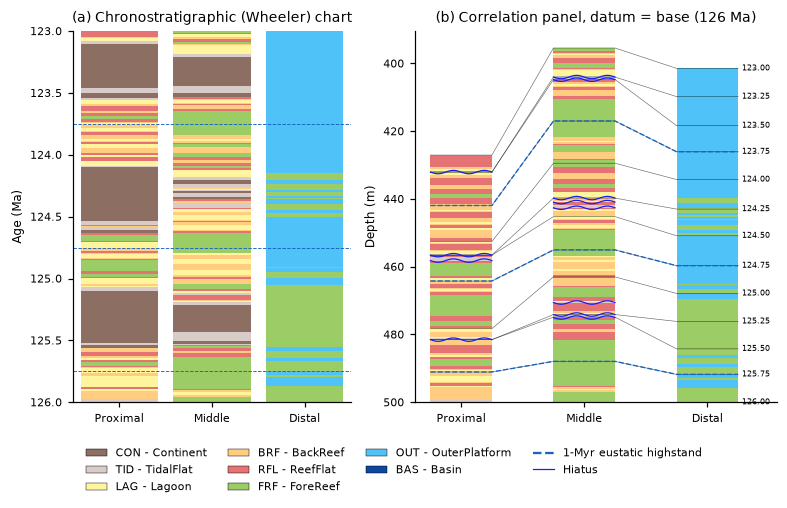

In [15]:
iso_ages = np.arange(T_START, T_END - 1e-9, -0.25)
highstand_ages = [T_START - 0.25 - k for k in range(3)]  # 1-Myr eustatic maxima

fig, axes = plt.subplots(1, 2, figsize=(7.2, 4.0), gridspec_kw={"width_ratios": [1, 1.3]})
ax = axes[0]
for r, name in enumerate(TRANSECT):
    plot_time_column(ax, ds3.time.values, ds3.dt.values, ds3.environment[r].values, x0=r * 1.2)
for a in highstand_ages:
    ax.axhline(a, color="#1565c0", lw=0.6, ls="--")
ax.set_xlim(-0.1, 3.5)
ax.set_ylim(T_START, T_END)
ax.set_xticks([0.5, 1.7, 2.9], list(TRANSECT))
ax.set_ylabel("Age (Ma)")
ax.set_title("(a) Chronostratigraphic (Wheeler) chart")

ax = axes[1]
x_positions = [0.0, 1.6, 3.2]
iso_depths = np.array(
    [simulatedAgesToDepths(ds3, r, iso_ages, BASE_DEPTH) for r in range(len(TRANSECT))]
)  # (well, age), depth below the common base datum
hs_depths = np.array([simulatedAgesToDepths(ds3, r, highstand_ages, BASE_DEPTH) for r in range(len(TRANSECT))])
for r, name in enumerate(TRANSECT):
    plot_depth_column(ax, transect_sim.simulatedWells[r].getDepthLog("Environment"), x0=x_positions[r], width=0.8)
    draw_hiatus(ax, hiatus_depths(transect_sim.simulatedWells[r]), x0=x_positions[r], x1=x_positions[r] + 0.8, n_waves=2)
for k in range(len(iso_ages)):
    xs = np.repeat(x_positions, 2) + np.tile([0.0, 0.8], 3)
    ys = np.repeat(iso_depths[:, k], 2)
    ax.plot(xs, ys, color="k", lw=0.4, alpha=0.6)
    ax.text(x_positions[-1] + 0.85, iso_depths[-1, k], f"{iso_ages[k]:.2f}", fontsize=5, va="center")
for k in range(len(highstand_ages)):
    xs = np.repeat(x_positions, 2) + np.tile([0.0, 0.8], 3)
    ax.plot(xs, np.repeat(hs_depths[:, k], 2), color="#1565c0", lw=0.9, ls="--")
ax.set_xlim(-0.2, 4.5)
ax.set_ylim(BASE_DEPTH, BASE_DEPTH - float(ds3.thickness_cumul[:, -1].max()) - 5)
ax.set_xticks([x + 0.4 for x in x_positions], list(TRANSECT))
ax.set_ylabel("Depth (m)")
ax.set_title("(b) Correlation panel, datum = base (126 Ma)")
fig.legend(
    handles=env_legend_handles()
    + [plt.Line2D([], [], color="#1565c0", ls="--", label="1-Myr eustatic highstand"), hiatus_legend_handle()],
    loc="upper center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, 0.0),
)
fig.tight_layout()
save_figure(fig, "fig_step3_transect")
plt.show()

**Figure 5 — Multi-well transect: one scenario, three realizations**
(`fig_step3_transect`).

*What it shows.* That a single scenario (eustasy, producers, environments)
produces contrasting successions when only the realization parameters change
(initial water depth and subsidence: proximal 2 m and 25 m/Myr, middle 8 m
and 35 m/Myr, distal 20 m and 45 m/Myr), and how time lines cut across
facies.

*Panels.*
- **(a) Chronostratigraphic (Wheeler) chart.** Environment of each well
  against age. Exposure (continent) intervals are hiatuses. Dashed blue lines
  are the 1-Myr eustatic highstands.
- **(b) Correlation panel.** Environment logs in depth, hung on the common
  base (126 Ma). Grey lines are isochrons every 0.25 Myr (ages on the right),
  dashed blue lines the 1-Myr highstands and blue wavy lines the hiatuses.

*Observations.* The proximal well is exposed during each lowstand for about
0.4 Myr (a) and records 73 m of mostly platform-top facies, with hiatuses at
each lowstand (b). The middle well keeps up: it alternates fore-reef at the
highstands and lagoon/back-reef/reef flat during the rises and falls, with
shorter exposures, over 105 m. The distal well alternates fore-reef and outer
platform, then drowns at about 124.15 Ma and only accumulates outer-platform
deposits afterwards (99 m in total). In (b), isochrons are close together in
the proximal well and in the drowned distal well, and widely spaced in the
productive middle well.

*Interpretation.* The environment belts are diachronous: a facies boundary is
not a time line, and the same eustatic event is expressed by different
facies, or by a hiatus, in each well. Thickness depends on production and
preservation, not only on accommodation: the distal well, with the largest
subsidence, is thinner than the middle well because its subsidence outpaces
the production of its deeper environments (incipient drowning). This is the
setting in which multi-well data constrain a scenario better than a single
well (Step 4b).

## Step 4 — Closing the loop

A **truth** well is simulated with the Step 0 scenario, starting on the reef
flat (3 m of water, `initialEnvironmentName="ReefFlat"`). Starting in an
environment with a narrow water-depth range (0-8 m) provides a well-constrained
datum at the base of the column, as a geologist would choose a reef-flat or
tidal-flat facies, or an exposure surface, to anchor an interpretation. The
truth is then turned into an "observed" well by degrading it the way real data
are degraded:

* the environment log is resampled at 0.5 m (majority label per bin), mimicking
  the resolution of a core description or electrofacies log;
* six dated surfaces at irregular ages (e.g., biostratigraphic markers) are
  picked at their true depths.

At this resolution the observed log is almost identical to the truth, so only
the truth is shown in the figures.

### 4a. Accommodation recovered from the observed well

`AccommodationSpaceWellCalculator` computes apparent accommodation from the
facies log: deposited thickness plus the change of water depth since the base,
where water depth is only known as the range of each environment. The water
depth at the base is the datum of the whole curve: by default it is the range
of the basal environment, but it can be given when it is known independently
(`waterDepthAtBase`). At each facies boundary, accommodation is estimated from
the water-depth range of the interval below and of the interval above; by
default the recovered range spans both estimates (`AccommodationBoundaryRule.UNION`),
which does not assume that the water depth at the boundary lies in both
ranges. Inside the range, the best estimate of accommodation is either the
middle of the range at each boundary (`AccommodationEstimateMethod.MIDPOINT`)
the most likely water depth of each facies (`AccommodationEstimateMethod.MODE`,
the middle of the facies range here since no mode is given), or the smoothest
curve within the range close to these modes
(`AccommodationEstimateMethod.SMOOTH`), which damps variations with a
wavelength shorter than `smoothingLength` (10 m of rock here, about a third of
the thickness deposited during a 1-Myr cycle) and
keeps a single datum for the water depth at the base. Since the synthetic
column has no compaction, the true accommodation is known exactly.

In [16]:
from pywellsfm import AccommodationBoundaryRule, AccommodationEstimateMethod

TRUTH_WD0, TRUTH_ENV = 3.0, "ReefFlat"
SMOOTHING_LENGTH = 10.0  # m, wavelength damped by the smooth estimate
truth_realization = make_realization("W-truth", TRUTH_WD0, 35.0, initial_environment=TRUTH_ENV)
truth_sim, _ = run_simulation(make_scenario(), [truth_realization], seed=42)
ds4 = truth_sim.outputs
truth_log = truth_sim.simulatedWells[0].getDepthLog("Environment")
print(f"Truth well: {float(ds4.thickness_cumul[0, -1]):.1f} m, first environment: {ds4.environment[0, 0].values}")

OBS_STEP = 0.5  # m
obs_log = resampleStriplog(truth_log, OBS_STEP)
observed_well = Well("W-truth observed", np.zeros(3), BASE_DEPTH)
observed_well.addLog("Environment", obs_log)
basal_environment = sorted(obs_log, key=lambda iv: iv.base.z)[-1].primary["lithology"]
print(f"Basal environment of the observed log: {basal_environment}")

marker_ages = np.array([125.6, 125.1, 124.7, 124.2, 123.8, 123.0])  # Ma
marker_depths_obs = simulatedAgesToDepths(ds4, 0, marker_ages, BASE_DEPTH)
observed_well.addMarkers(
    [Marker("Base", BASE_DEPTH, T_START)] + [Marker(f"M{a:.1f}", d, a) for a, d in zip(marker_ages, marker_depths_obs)]
)

facies = faciesFromDepositionalEnvironments(environment_model, minWaterDepth=-5.0, maxWaterDepth=200.0)

# truth in depth: accommodation at the end of each step, relative to the start
depth_true = simulatedStepEndDepths(ds4, 0, BASE_DEPTH)
acco_true = ds4.accommodation[0].values


def recover_accommodation(**kwargs):
    """Accommodation recovered from the observed well, and scores vs truth."""
    calculator = AccommodationSpaceWellCalculator(observed_well, facies)
    curve = calculator.computeAccommodationCurve("Environment", **kwargs)
    d, med, lo, hi = curve.getAbscissa(), curve.getMedianValues(), curve.getMinValues(), curve.getMaxValues()
    # the curve is initialized with undefined values at the well head and well
    # bottom; keep defined samples only
    ok = np.isfinite(med) & np.isfinite(lo) & np.isfinite(hi)
    d, med, lo, hi = d[ok], med[ok], lo[ok], hi[ok]
    true = np.interp(d, depth_true[::-1], acco_true[::-1])
    scores = {
        "coverage_pct": 100 * np.mean((true >= lo - 1e-6) & (true <= hi + 1e-6)),
        "mean_range_width_m": np.mean(hi - lo),
        "estimate_bias_m": np.mean(med - true),
        "estimate_rmse_m": np.sqrt(np.mean((med - true) ** 2)),
    }
    return {"depth": d, "median": med, "min": lo, "max": hi}, scores


recoveries = {
    "Base from facies, union (default)": recover_accommodation(),
    f"Base water depth known ({TRUTH_WD0:g} m), union": recover_accommodation(waterDepthAtBase=TRUTH_WD0),
    "Base from facies, intersection": recover_accommodation(boundaryRule=AccommodationBoundaryRule.INTERSECTION),
    "Base from facies, union, smooth estimate": recover_accommodation(
        estimateMethod=AccommodationEstimateMethod.SMOOTH, smoothingLength=SMOOTHING_LENGTH
    ),
}
recovery_table = pd.DataFrame({k: v[1] for k, v in recoveries.items()}).T
recovery_table.to_csv(os.path.join(OUTPUT_DIR, "table_step4a_accommodation_recovery.csv"))
recovery_table.round(1)

Truth well: 102.4 m, first environment: ReefFlat
Basal environment of the observed log: ReefFlat


,coverage_pct,mean_range_width_m,estimate_bias_m,estimate_rmse_m
"Base from facies, union (default)",98.2,22.0,0.5,5.7
"Base water depth known (3 m), union",86.0,14.1,1.5,5.9
"Base from facies, intersection",93.0,14.5,-1.9,3.7
"Base from facies, union, smooth estimate",98.2,22.0,-1.4,3.4


Correlation of the accommodation derivatives with the truth: smooth estimate 0.83, midpoint 0.67


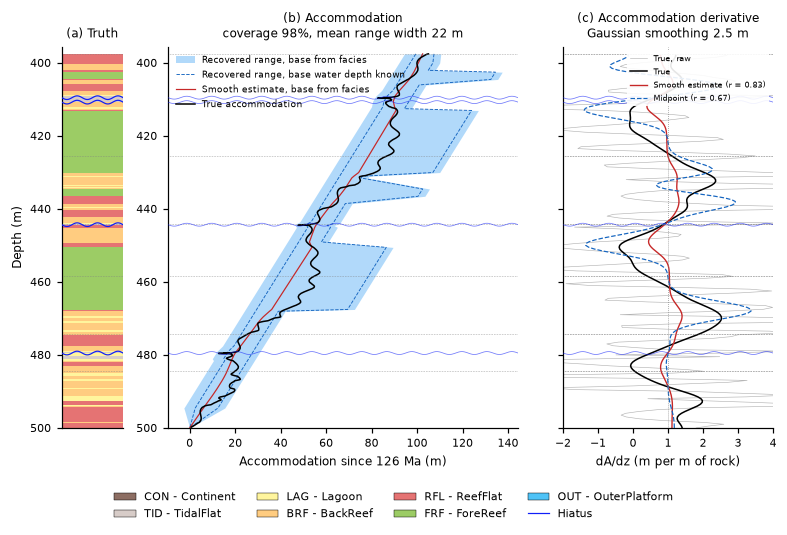

In [17]:
default_rec, default_scores = recoveries["Base from facies, union (default)"]
known_rec, _ = recoveries[f"Base water depth known ({TRUTH_WD0:g} m), union"]

from scipy.ndimage import gaussian_filter1d

# accommodation derivative with respect to depth (m of accommodation per m of rock)
DERIV_STEP, DERIV_SIGMA = 0.5, 2.5  # m: sampling step and Gaussian smoothing width


def accommodation_on_grid(depth, acco, grid):
    """Accommodation interpolated on a depth grid (depth increases downward)."""
    order = np.argsort(-np.asarray(depth), kind="stable")
    return np.interp(-grid, -np.asarray(depth)[order], np.asarray(acco)[order])


def accommodation_derivative(acco_grid, grid, sigma=None):
    """dA/dz per m of rock (upward), optionally smoothed by a Gaussian of width sigma (m)."""
    deriv = -np.gradient(acco_grid, grid)
    return gaussian_filter1d(deriv, sigma / DERIV_STEP) if sigma else deriv


deriv_grid = np.arange(BASE_DEPTH, BASE_DEPTH - float(ds4.thickness_cumul[0, -1]), -DERIV_STEP)
smooth_rec, _ = recoveries["Base from facies, union, smooth estimate"]
deriv_true_raw = accommodation_derivative(accommodation_on_grid(depth_true, acco_true, deriv_grid), deriv_grid)
deriv_true = accommodation_derivative(accommodation_on_grid(depth_true, acco_true, deriv_grid), deriv_grid, DERIV_SIGMA)
deriv_smooth = accommodation_derivative(
    accommodation_on_grid(smooth_rec["depth"], smooth_rec["median"], deriv_grid), deriv_grid, DERIV_SIGMA
)
deriv_mid = accommodation_derivative(
    accommodation_on_grid(default_rec["depth"], default_rec["median"], deriv_grid), deriv_grid, DERIV_SIGMA
)
corr_smooth = np.corrcoef(deriv_true, deriv_smooth)[0, 1]
corr_mid = np.corrcoef(deriv_true, deriv_mid)[0, 1]
print(f"Correlation of the accommodation derivatives with the truth: smooth estimate {corr_smooth:.2f}, midpoint {corr_mid:.2f}")

fig, axes = plt.subplots(1, 3, figsize=(7.2, 4.4), gridspec_kw={"width_ratios": [0.35, 2, 1.2]})
plot_depth_column(axes[0], truth_log)
axes[0].set_xlim(0, 1)
axes[0].set_xticks([])
ax = axes[1]
ax.fill_betweenx(
    default_rec["depth"], default_rec["min"], default_rec["max"], color="#90caf9", alpha=0.7, lw=0,
    label="Recovered range, base from facies",
)
ax.plot(known_rec["min"], known_rec["depth"], color="#1565c0", lw=0.6, ls="--", label="Recovered range, base water depth known")
ax.plot(known_rec["max"], known_rec["depth"], color="#1565c0", lw=0.6, ls="--")
ax.plot(smooth_rec["median"], smooth_rec["depth"], color="#c62828", lw=0.8, label="Smooth estimate, base from facies")
ax.plot(acco_true, depth_true, color="k", lw=1.0, label="True accommodation")
for d in marker_depths_obs:
    for a in axes:
        a.axhline(d, color="grey", lw=0.4, ls=":")
truth_hiatus = hiatus_depths(truth_sim.simulatedWells[0])
draw_hiatus(axes[0], truth_hiatus)
draw_hiatus(axes[1], truth_hiatus, n_waves=14, amplitude=0.4, across=True, lw=0.5, alpha=0.6)
ax.set_xlabel("Accommodation since 126 Ma (m)")
ax.legend(frameon=False, loc="upper left", fontsize=6)
ax.set_title(
    f"(b) Accommodation\ncoverage {default_scores['coverage_pct']:.0f}%, mean range width {default_scores['mean_range_width_m']:.0f} m",
    fontsize=8,
)
ax = axes[2]
ax.plot(deriv_true_raw, deriv_grid, color="grey", lw=0.4, alpha=0.6, label="True, raw")
ax.plot(deriv_true, deriv_grid, color="k", lw=1.0, label="True")
ax.plot(deriv_smooth, deriv_grid, color="#c62828", lw=0.9, label=f"Smooth estimate (r = {corr_smooth:.2f})")
ax.plot(deriv_mid, deriv_grid, color="#1565c0", lw=0.8, ls="--", label=f"Midpoint (r = {corr_mid:.2f})")
ax.axvline(1.0, color="grey", lw=0.5, ls=":")
for d in marker_depths_obs:
    ax.axhline(d, color="grey", lw=0.4, ls=":")
draw_hiatus(ax, truth_hiatus, n_waves=8, amplitude=0.4, across=True, lw=0.5, alpha=0.6)
ax.set_xlim(-2, 4)
ax.set_xlabel("dA/dz (m per m of rock)")
ax.set_yticklabels([])
ax.set_title(f"(c) Accommodation derivative\nGaussian smoothing {DERIV_SIGMA:g} m", fontsize=8)
ax.legend(frameon=True, framealpha=0.9, edgecolor="none", loc="upper right", fontsize=5.5)
axes[0].set_title("(a) Truth", fontsize=8)
top = BASE_DEPTH - float(ds4.thickness_cumul[0, -1])
for a in axes:
    a.set_ylim(BASE_DEPTH, top - 2)
axes[0].set_ylabel("Depth (m)")
fig.legend(
    handles=env_legend_handles(ENVIRONMENTS[:7]) + [hiatus_legend_handle()],
    loc="upper center", ncol=4, frameon=False, bbox_to_anchor=(0.5, 0.0),
)
fig.tight_layout()
save_figure(fig, "fig_step4a_accommodation_recovery")
plt.show()

**Figure 6 — Accommodation recovered from the observed truth well**
(`fig_step4a_accommodation_recovery`).

*What it shows.* How well `AccommodationSpaceWellCalculator` recovers the
true accommodation from a facies log alone, where water depth is only known
as the range of each environment, and whether the recovered curve captures
the variations of accommodation, not only its trend.

*Panels.*
- **(a) Truth.** Environment log of the truth well in depth. Blue wavy lines
  are hiatuses.
- **(b) Accommodation since 126 Ma** against depth: recovered range with the
  default settings (blue band: union rule, base water depth from the basal
  reef flat, 0-8 m), recovered range when the base water depth is known
  (dashed lines, 3 m), smooth estimate with the default settings (red line)
  and true accommodation (black). Dotted grey lines are the dated surfaces;
  the thin blue wavy lines repeat the hiatuses.
- **(c) Accommodation derivative** dA/dz, i.e. accommodation created per
  metre of rock deposited: true (thin grey: raw, 0.5 m sampling; black:
  smoothed), smooth estimate (red) and midpoint of the range (dashed blue).
  The recovered and true curves are smoothed with the same Gaussian (2.5 m)
  so that they are compared at the same vertical resolution. The dotted line
  dA/dz = 1 is keep-up (constant water depth): above 1 the water deepens
  upward, below 1 it shallows upward. The correlation with the smoothed true
  derivative is given in the legend.

*Observations.* The default range contains the true accommodation over 98% of
the well, with a mean width of 22 m (b). The range widens in the fore-reef
intervals (≈ 413-430 m and 450-467 m), since a fore-reef bed only says that
water depth was between 5 and 40 m. It is narrow in the platform-top
intervals (0-10 m). Knowing the base water depth narrows the range to 14 m,
but the coverage drops to 86%: the truth leaves the dashed range at the
hiatuses (horizontal steps of the true curve at ≈ 480, 445 and 410 m), where
sea level fell below the exposed platform without leaving any deposit. The
smooth estimate follows the trend of the truth with a bias of -1.4 m and an
RMSE of 3.4 m, against 0.5 m and 5.7 m for the midpoint of the range and 3.7
m for the intersection rule (table above). In (c), the true derivative
oscillates between about -0.5 and 2.5 with the 1-Myr cycle: it exceeds 1
below each fore-reef interval (deepening during the rises, ≈ 430-440 m and
465-475 m) and falls below 1 in the fore-reef and below the hiatuses
(shallowing at the highstands and during the falls, ≈ 413-425, 448-458 and
480-488 m). Both recovered derivatives are in phase with the truth (r = 0.83
for the smooth estimate, 0.67 for the midpoint). The smooth estimate has the
right phase but a much smaller amplitude (0.4-1.4); the midpoint has the
right amplitude but jumps at each facies change.

*Interpretation.* The recovered range is an honest bracket of accommodation
rather than a point estimate: its width is set by the water-depth ranges of
the facies, so facies with narrow ranges (reef flat, tidal flat, exposure
surfaces) are the anchors of the curve. The union rule is wider than the
intersection rule but robust to fast facies changes. The derivative shows
that the recovered curve carries the **timing of the accommodation cycles**
(deepening-upward and shallowing-upward intervals) even where its absolute
value is uncertain: this is the information used to identify transgressive
and regressive trends, and it does not depend on the datum at the base. The
smooth estimate is the best single curve but damps the amplitude of the
cycles, and neither estimate can recover what the facies do not record
(variations inside a fore-reef interval or across a hiatus).

**Accommodation along the transect.** The same recovery is applied to the three
wells of Step 3, observed in the same way (environment log at 0.5 m, dated
surfaces at the same ages). The recovered accommodation is shown in depth for
each well, with the dated surfaces and the 1-Myr highstands correlated between
the wells. Depths are then converted to ages by linear interpolation between
the dated surfaces, as would be done with biostratigraphic markers, and the
correlation lines are carried to the age axis of the last panel. The wells
differ by their subsidence (25, 35 and 45 m/Myr) but share the same eustasy:
removing a linear trend from each recovered curve should leave a common
eustatic signal. The smooth estimate is used as the best estimate of each well
(independently from the others); the error of the midpoint is reported for
comparison.

In [18]:
def well_age_model(depths, marker_d, marker_a):
    """Ages of depths by linear interpolation between dated surfaces."""
    order = np.argsort(marker_d)
    return np.interp(depths, np.asarray(marker_d)[order], np.asarray(marker_a)[order])


def detrend(age, values):
    """Residual of a least-squares linear fit against age."""
    ok = np.isfinite(values)
    coef = np.polyfit(age[ok], values[ok], 1)
    return values - np.polyval(coef, age)


sea_t = ds3.time.values - ds3.dt.values
sea = ds3.sea_level.values
transect_recovery, transect_rows = {}, []
for r, name in enumerate(TRANSECT):
    log_r = resampleStriplog(transect_sim.simulatedWells[r].getDepthLog("Environment"), OBS_STEP)
    m_depths = simulatedAgesToDepths(ds3, r, marker_ages, BASE_DEPTH)
    well_r = Well(f"{name} observed", np.zeros(3), BASE_DEPTH)
    well_r.addLog("Environment", log_r)
    well_r.addMarkers([Marker("Base", BASE_DEPTH, T_START)] + [Marker(f"M{a:.1f}", d, a) for a, d in zip(marker_ages, m_depths)])
    curve = AccommodationSpaceWellCalculator(well_r, facies).computeAccommodationCurve("Environment")
    smooth_curve = AccommodationSpaceWellCalculator(well_r, facies).computeAccommodationCurve(
        "Environment", estimateMethod=AccommodationEstimateMethod.SMOOTH, smoothingLength=SMOOTHING_LENGTH
    )
    d, med, lo, hi = curve.getAbscissa(), curve.getMedianValues(), curve.getMinValues(), curve.getMaxValues()
    smooth = smooth_curve.getMedianValues()
    ok = np.isfinite(med) & np.isfinite(lo) & np.isfinite(hi)
    d, med, lo, hi, smooth = d[ok], med[ok], lo[ok], hi[ok], smooth[ok]
    age = well_age_model(d, np.r_[BASE_DEPTH, m_depths], np.r_[T_START, marker_ages])
    # truth on the time axis (accommodation at the end of each step)
    t_true = ds3.time.values - ds3.dt.values
    a_true = ds3.accommodation[r].values
    true_at = np.interp(age, t_true[::-1], a_true[::-1])
    sea_at = np.interp(age, sea_t[::-1], detrend(sea_t, sea)[::-1])
    transect_recovery[name] = {
        "depth": d, "age": age, "median": med, "smooth": smooth, "min": lo, "max": hi, "marker_depths": m_depths,
        "depth_true": simulatedStepEndDepths(ds3, r, BASE_DEPTH), "a_true": a_true,
        "hiatus": hiatus_depths(transect_sim.simulatedWells[r]),
    }
    transect_rows.append(
        {
            "well": name,
            "subsidence_m_per_Myr": TRANSECT[name][1],
            "basal_environment": sorted(log_r, key=lambda iv: iv.base.z)[-1].primary["lithology"],
            "coverage_pct": 100 * np.mean((true_at >= lo - 1e-6) & (true_at <= hi + 1e-6)),
            "mean_range_width_m": np.mean(hi - lo),
            "mid_range_rmse_m": np.sqrt(np.mean((med - true_at) ** 2)),
            "smooth_rmse_m": np.sqrt(np.mean((smooth - true_at) ** 2)),
            # phase of the detrended estimates with the detrended eustasy
            "eustasy_corr_midpoint": np.corrcoef(detrend(age, med), sea_at)[0, 1],
            "eustasy_corr_smooth": np.corrcoef(detrend(age, smooth), sea_at)[0, 1],
        }
    )
transect_recovery_table = pd.DataFrame(transect_rows).set_index("well")
transect_recovery_table.to_csv(os.path.join(OUTPUT_DIR, "table_step4a_transect_recovery.csv"))
transect_recovery_table.round(1)

,subsidence_m_per_Myr,basal_environment,coverage_pct,mean_range_width_m,mid_range_rmse_m,smooth_rmse_m,eustasy_corr_midpoint,eustasy_corr_smooth
well,,,,,,,,
Proximal,25.0,TidalFlat,64.5,16.7,9.7,6.5,0.4,0.7
Middle,35.0,ForeReef,91.3,53.4,12.6,9.3,0.4,0.6
Distal,45.0,ForeReef,96.0,219.8,65.1,33.7,0.3,0.6


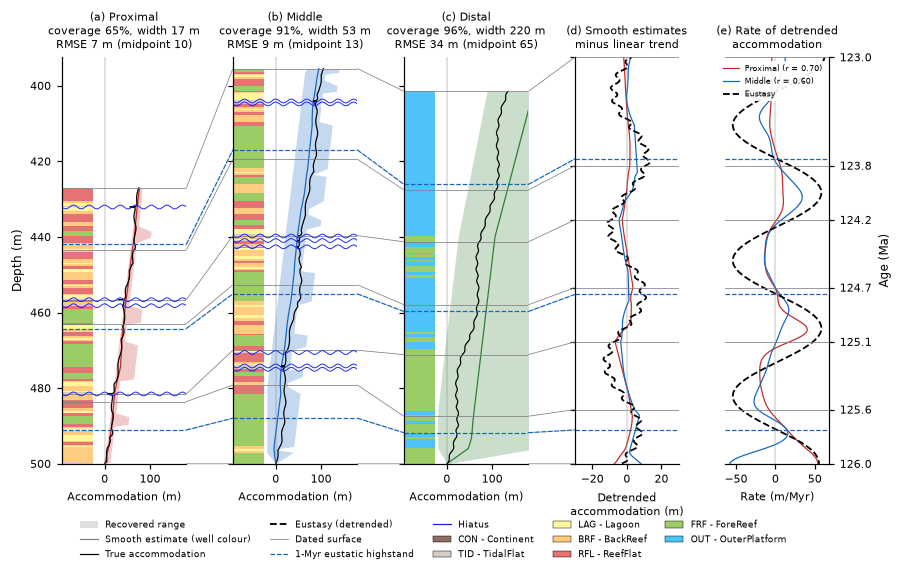

In [19]:
WELL_COLORS = {"Proximal": "#c62828", "Middle": "#1565c0", "Distal": "#2e7d32"}
from matplotlib.patches import ConnectionPatch

# correlation surfaces: the dated surfaces of the age model and the 1-Myr highstands
corr_ages = np.r_[T_START, marker_ages]
corr_style = {"color": "grey", "lw": 0.5}
hs_style = {"color": "#1565c0", "lw": 0.8, "ls": "--"}
hs_depths_4 = {name: simulatedAgesToDepths(ds3, r, highstand_ages, BASE_DEPTH) for r, name in enumerate(TRANSECT)}
corr_depths = {name: np.r_[BASE_DEPTH, rec["marker_depths"]] for name, rec in transect_recovery.items()}

# accommodation rate (time derivative of the detrended curves), smoothed in time
RATE_STEP, RATE_SIGMA = 0.005, 0.075  # Myr: sampling step and Gaussian smoothing width
rate_grid = np.arange(T_END, T_START + 1e-9, RATE_STEP)


def on_age_grid(age, values):
    order = np.argsort(age)
    return np.interp(rate_grid, np.asarray(age)[order], np.asarray(values)[order])


def smoothed_rate(age, values):
    """Smoothed time derivative (m/Myr, forward in time) of a curve given against age."""
    rate = -np.gradient(on_age_grid(age, values), rate_grid)
    return gaussian_filter1d(rate, RATE_SIGMA / RATE_STEP)


eustatic_rate = smoothed_rate(sea_t, detrend(sea_t, sea))
recovered_rates = {name: smoothed_rate(rec["age"], detrend(rec["age"], rec["smooth"])) for name, rec in transect_recovery.items()}
transect_recovery_table["rate_corr_smooth"] = [
    np.corrcoef(eustatic_rate, recovered_rates[name])[0, 1] for name in transect_recovery_table.index
]
transect_recovery_table.to_csv(os.path.join(OUTPUT_DIR, "table_step4a_transect_recovery.csv"))

fig, axes = plt.subplots(
    1, 5, figsize=(9.0, 4.8), gridspec_kw={"width_ratios": [1.2, 1.2, 1.2, 1.0, 1.0], "wspace": 0.4}
)
ACC_MIN, ACC_MAX = -20.0, 180.0  # accommodation range shown in the well panels (m)
LOG_X1 = ACC_MIN - 6.0  # litho log drawn at negative x, 1/4 of the panel width
LOG_WIDTH = (ACC_MAX - LOG_X1) / 3.0
LOG_X0 = LOG_X1 - LOG_WIDTH
depth_top = BASE_DEPTH - float(ds3.thickness_cumul[:, -1].max()) - 3
letters = iter("abcde")
for ax, (name, rec) in zip(axes[:3], transect_recovery.items()):
    color = WELL_COLORS[name]
    r = list(TRANSECT).index(name)
    plot_depth_column(ax, transect_sim.simulatedWells[r].getDepthLog("Environment"), x0=LOG_X0, width=LOG_WIDTH)
    ax.fill_betweenx(
        rec["depth"], np.maximum(rec["min"], ACC_MIN), rec["max"], color=color, alpha=0.25, lw=0, label="Recovered range"
    )
    ax.plot(np.maximum(rec["smooth"], ACC_MIN), rec["depth"], color=color, lw=0.8, label="Smooth estimate")
    ax.plot(rec["a_true"], rec["depth_true"], color="k", lw=0.8, label="True")
    for dd in corr_depths[name]:
        ax.axhline(dd, **corr_style)
    for dd in hs_depths_4[name]:
        ax.axhline(dd, **hs_style)
    draw_hiatus(ax, rec["hiatus"], n_waves=8, amplitude=0.5, across=True, lw=0.6)
    row = transect_recovery_table.loc[name]
    ax.set_title(
        f"({next(letters)}) {name}\ncoverage {row.coverage_pct:.0f}%, width {row.mean_range_width_m:.0f} m\n"
        f"RMSE {row.smooth_rmse_m:.0f} m (midpoint {row.mid_range_rmse_m:.0f})",
        fontsize=7,
    )
    ax.set_xlabel("Accommodation (m)", fontsize=7)
    ax.set_xlim(LOG_X0, ACC_MAX)
    ax.set_xticks([0, 100])
    ax.set_ylim(BASE_DEPTH, depth_top)
    if ax is not axes[0]:
        ax.set_yticklabels([])
axes[0].set_ylabel("Depth (m)")

ax = axes[3]
for name, rec in transect_recovery.items():
    if name == "Distal":
        continue  # drowned: outer-platform facies (30-200 m) do not constrain water depth
    ax.plot(detrend(rec["age"], rec["smooth"]), rec["age"], color=WELL_COLORS[name], lw=0.8, label=name)
ax.plot(detrend(sea_t, sea), sea_t, color="k", lw=1.2, ls="--", label="Eustasy (detrended)")
for a in corr_ages:
    ax.axhline(a, **corr_style)
for a in highstand_ages:
    ax.axhline(a, **hs_style)
ax.set_xlabel("Detrended\naccommodation (m)", fontsize=7)
ax.set_title(f"({next(letters)}) Smooth estimates\nminus linear trend", fontsize=7)
ax.set_xlim(-30, 30)
ax.set_ylim(T_START, T_END)
ax.set_yticks(corr_ages, [])

ax = axes[4]
for name in transect_recovery:
    if name == "Distal":
        continue
    r_rate = transect_recovery_table.loc[name, "rate_corr_smooth"]
    ax.plot(recovered_rates[name], rate_grid, color=WELL_COLORS[name], lw=0.8, label=f"{name} (r = {r_rate:.2f})")
ax.plot(eustatic_rate, rate_grid, color="k", lw=1.2, ls="--", label="Eustasy")
for a in corr_ages:
    ax.axhline(a, **corr_style)
for a in highstand_ages:
    ax.axhline(a, **hs_style)
ax.set_xlabel("Rate (m/Myr)", fontsize=7)
ax.set_title(f"({next(letters)}) Rate of detrended\naccommodation", fontsize=7)
ax.set_ylim(T_START, T_END)
ax.set_yticks(corr_ages, [f"{a:.1f}" for a in corr_ages])
ax.legend(frameon=True, framealpha=0.9, edgecolor="none", loc="upper right", fontsize=5)
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
ax.spines["left"].set_visible(False)
ax.spines["right"].set_visible(True)
ax.set_ylabel("Age (Ma)")
for a in axes:
    a.axvline(0, color="grey", lw=0.3)
axes[3].spines["right"].set_visible(False)

# correlation lines between the wells, then from the distal well to the age axis
names = list(transect_recovery)
for k in range(len(corr_ages)):
    for i in range(2):
        fig.add_artist(ConnectionPatch(
            xyA=(1, corr_depths[names[i]][k]), coordsA=axes[i].get_yaxis_transform(),
            xyB=(0, corr_depths[names[i + 1]][k]), coordsB=axes[i + 1].get_yaxis_transform(), **corr_style))
    fig.add_artist(ConnectionPatch(
        xyA=(1, corr_depths[names[2]][k]), coordsA=axes[2].get_yaxis_transform(),
        xyB=(0, corr_ages[k]), coordsB=axes[3].get_yaxis_transform(), **corr_style))
for k in range(len(highstand_ages)):
    for i in range(2):
        fig.add_artist(ConnectionPatch(
            xyA=(1, hs_depths_4[names[i]][k]), coordsA=axes[i].get_yaxis_transform(),
            xyB=(0, hs_depths_4[names[i + 1]][k]), coordsB=axes[i + 1].get_yaxis_transform(), **hs_style))
    fig.add_artist(ConnectionPatch(
        xyA=(1, hs_depths_4[names[2]][k]), coordsA=axes[2].get_yaxis_transform(),
        xyB=(0, highstand_ages[k]), coordsB=axes[3].get_yaxis_transform(), **hs_style))

handles = [
    plt.Rectangle((0, 0), 1, 1, color="grey", alpha=0.25, lw=0, label="Recovered range"),
    plt.Line2D([], [], color="grey", lw=0.8, label="Smooth estimate (well colour)"),
    plt.Line2D([], [], color="k", lw=0.8, label="True accommodation"),
    plt.Line2D([], [], color="k", lw=1.2, ls="--", label="Eustasy (detrended)"),
    plt.Line2D([], [], **corr_style, label="Dated surface"),
    plt.Line2D([], [], **hs_style, label="1-Myr eustatic highstand"),
    hiatus_legend_handle(),
] + env_legend_handles(ENVIRONMENTS[:7])
fig.legend(handles=handles, loc="upper center", ncol=5, frameon=False, bbox_to_anchor=(0.5, 0.02), fontsize=6)
save_figure(fig, "fig_step4a_transect_accommodation")
plt.show()

**Figure 7 — Accommodation recovered along the transect**
(`fig_step4a_transect_accommodation`).

*What it shows.* The same recovery applied to the three wells of Step 3, and
whether the recovered curves, once corrected for subsidence, record the
common eustatic signal and its rate.

*Panels.*
- **(a-c) Proximal, middle and distal wells** in depth, hung on the common
  base (500 m). On the left of each panel, the environment log. On the right,
  the recovered accommodation range (shaded), the smooth estimate (coloured
  line) and the true accommodation (black). Grey lines are the dated surfaces
  used for the age model and dashed blue lines the 1-Myr highstands, both
  correlated between the wells. Blue wavy lines are hiatuses. The title gives
  the coverage, the mean range width and the RMSE of the smooth estimate (and
  of the midpoint of the range).
- **(d) Smooth estimates minus a linear trend** (the subsidence), against
  age, for the proximal and middle wells, compared with the detrended
  eustatic curve (dashed black). Depths are converted to ages by linear
  interpolation between the dated surfaces; the correlation lines continue
  through panel (e) to the age axis on the right.
- **(e) Rate of detrended accommodation**: time derivative (m/Myr) of the
  curves of (d), i.e. accommodation rate minus the mean subsidence rate of
  each well, compared with the rate of eustatic change (dashed black). All
  curves are smoothed with the same Gaussian (0.075 Myr, about 2.5 m of rock
  in the middle well, as in Figure 6) and the correlation with the eustatic
  rate is given in the legend.

*Observations.* In the proximal well (a), platform-top facies give a narrow
range (17 m) and the smooth estimate has an RMSE of 6.5 m, but the coverage
is only 65%: during each lowstand the true accommodation drops below the
exposed platform (horizontal steps at the hiatuses) and no deposit records
it. In the middle well (b), the basal fore-reef (5-40 m) makes the datum
uncertain: the range is wide (53 m, coverage 91%) and the smooth estimate is
shifted below the truth by about 15 m along the whole well (RMSE 9.3 m),
since its datum is the middle of the fore-reef range (22.5 m) while the well
started in 8 m of water. In the distal well (c), the outer-platform facies
(30-200 m) of the drowned interval leave accommodation essentially
unconstrained (220 m wide, RMSE 34 m). In (d), the detrended estimates of the
proximal and middle wells oscillate in phase with eustasy: their maxima fall
on the 1-Myr highstands (correlation 0.73 and 0.63, against 0.36 for the
midpoints of the range). Their amplitude is about half the eustatic one (±12
m), and the 100-kyr cycles are not resolved. In (e), the recovered rates
follow the eustatic rate (correlation 0.70 in the proximal well and 0.60 in
the middle well, 0.34 in the distal well, not shown): they are positive
during the rises (≈ 125.0 and 124.0 Ma) and negative during the falls, and
cross zero near the 1-Myr highstands (dashed blue lines), with a smaller
amplitude (about ±20-40 m/Myr against ±60 m/Myr). The rate of the middle well
is distorted at the very base (≈ 126 Ma), where the smooth estimate bends to
its basal fore-reef datum.

*Interpretation.* The quality of the recovery is controlled by the facies,
not by the method: narrow-range facies give tight brackets, deep or
wide-range facies give almost no constraint, and exposure intervals are
invisible. The basal facies matters most, since its range is the datum of the
whole curve. Comparing wells with different subsidence separates the shared
eustatic signal from local subsidence: in phase between wells and with
eustasy, but damped, because the smoothing removes part of the cycle together
with the facies jumps and the hiatuses remove the lowstands. The rate panel
(e) confirms that the timing of the accommodation cycles, i.e. when
accommodation is created and when it is not, is recovered better than its
absolute value. The distal well is left out of (d) and (e) because its
recovered curve carries no water-depth information after drowning. A mode
closer to the typical fore-reef water depth than the middle of its range
would reduce the datum shift of the middle well.

### 4b. Brute-force parameter sweep

The forward model is now run over a regular grid of three parameters, the
others being fixed to their true values:

* amplitude of the 1-Myr eustatic cycle (scenario parameter),
* production factor scaling all maximum accumulation rates (scenario parameter),
* subsidence rate (realization parameter).

`runParameterSweep` builds one simulator per combination of scenario parameters
with one realization per subsidence rate, so that all subsidence values share
the same time loop. Each realization is compared with the observed well through
misfits based on different data types:

* **marker misfit**: RMSE between observed and simulated depths of the dated
  surfaces (thickness and timing information);
* **facies misfit**: total variation distance between the environment thickness
  proportions of the observed log and of the simulated log degraded the same
  way (0 = same proportions, 1 = nothing in common);
* for reference, the fraction of mismatching environments when both logs are
  aligned on the base, sample by sample.

The sweep uses a different random seed than the truth, so even the true
parameters do not give zero misfits: this is the irreducible stochastic misfit
of the environment selector, estimated below from 20 realizations of the true
parameters.

In [20]:
scenario_grid = {"amplitude_3rd": [0.0, 2.5, 5.0, 7.5, 10.0, 12.5, 15.0, 17.5, 20.0], "production_factor": [0.5, 0.75, 1.0, 1.25, 1.5, 2.0]}
realization_grid = {"subsidence_rate": [25.0, 27.5, 30.0, 32.5, 35.0, 37.5, 40.0, 42.5, 45.0]}
TRUE_PARAMS = {"amplitude_3rd": 10.0, "production_factor": 1.0, "subsidence_rate": 35.0}
SWEEP_SEED = 11
obs_proportions = thicknessProportions(*striplogToSequence(obs_log))


def build_sweep_simulator(scenario_params, realization_params_list):
    np.random.seed(SWEEP_SEED)
    return FSSimulator(
        make_scenario(**scenario_params),
        [make_realization("W", TRUTH_WD0, p["subsidence_rate"], TRUTH_ENV) for p in realization_params_list],
        use_depositional_environment_simulator=True,
        deSimulator_params=DE_PARAMS,
        fsSimulator_params=FS_PARAMS,
        seed=SWEEP_SEED,
    )


def evaluate_against_observed(sim, r, params):
    ds = sim.outputs
    sim_marker_depths = simulatedAgesToDepths(ds, r, marker_ages, BASE_DEPTH)
    sim_log = resampleStriplog(sim.simulatedWells[r].getDepthLog("Environment"), OBS_STEP)
    return {
        "marker_rmse_m": markerDepthRmse(marker_depths_obs, sim_marker_depths),
        "facies_distance": thicknessProportionDistance(obs_proportions, thicknessProportions(*striplogToSequence(sim_log))),
        "facies_mismatch": faciesMismatchFraction(obs_log, BASE_DEPTH, sim_log, BASE_DEPTH, step=0.1),
        "thickness_m": float(ds.thickness_cumul[r, -1]),
    }


# irreducible (stochastic) misfit: 20 realizations of the true parameters
floor_sim, _ = run_simulation(
    make_scenario(), [make_realization("W", TRUTH_WD0, 35.0, TRUTH_ENV) for _ in range(20)], seed=SWEEP_SEED
)
floor = pd.DataFrame([evaluate_against_observed(floor_sim, r, TRUE_PARAMS) for r in range(20)])
print("Misfits of the true parameters over 20 realizations (mean +/- std):")
print((floor.mean().round(3).astype(str) + " +/- " + floor.std().round(3).astype(str)).to_string())

sweep_start = time.perf_counter()
sweep = runParameterSweep(scenario_grid, build_sweep_simulator, evaluate_against_observed, realization_grid)
sweep_runtime = time.perf_counter() - sweep_start
sweep.to_csv(os.path.join(OUTPUT_DIR, "table_step4b_sweep.csv"), index=False)
n_runs = len(sweep)
print(f"\n{n_runs} forward runs in {sweep_runtime:.0f} s ({sweep_runtime / n_runs:.2f} s per realization)")

Misfits of the true parameters over 20 realizations (mean +/- std):
marker_rmse_m      2.563 +/- 0.823
facies_distance    0.073 +/- 0.035
facies_mismatch    0.548 +/- 0.054
thickness_m        99.88 +/- 1.081



486 forward runs in 293 s (0.60 s per realization)


Misfit maps on two planes through the true parameters (Figure 8).

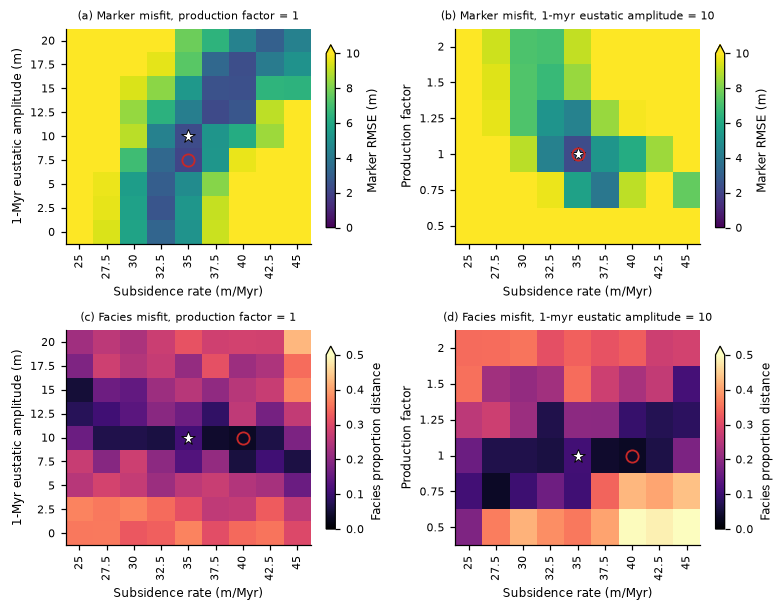

In [21]:
def misfit_map(ax, table, x, y, value, fixed, cmap, vmax=None, label=""):
    sub = table
    for k, v in fixed.items():
        sub = sub[np.isclose(sub[k], v)]
    grid = sub.pivot_table(index=y, columns=x, values=value)
    xs, ys = grid.columns.values, grid.index.values
    mesh = ax.pcolormesh(
        np.arange(len(xs) + 1), np.arange(len(ys) + 1), grid.values, cmap=cmap, vmin=0, vmax=vmax, shading="flat"
    )
    ax.set_xticks(np.arange(len(xs)) + 0.5, [f"{v:g}" for v in xs], rotation=90)
    ax.set_yticks(np.arange(len(ys)) + 0.5, [f"{v:g}" for v in ys])
    ax.plot(list(xs).index(TRUE_PARAMS[x]) + 0.5, list(ys).index(TRUE_PARAMS[y]) + 0.5, marker="*", color="w", mec="k", ms=9, mew=0.6)
    best = np.unravel_index(np.nanargmin(grid.values), grid.shape)
    ax.plot(best[1] + 0.5, best[0] + 0.5, marker="o", mfc="none", mec="#c62828", ms=8, mew=1.2)
    plt.colorbar(mesh, ax=ax, shrink=0.85, label=label, extend="max" if vmax is not None else "neither")


labels = {
    "amplitude_3rd": "1-Myr eustatic amplitude (m)",
    "production_factor": "Production factor",
    "subsidence_rate": "Subsidence rate (m/Myr)",
}
planes = [
    ("subsidence_rate", "amplitude_3rd", {"production_factor": 1.0}),
    ("subsidence_rate", "production_factor", {"amplitude_3rd": 10.0}),
]
fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.6))
for i, (x, y, fixed) in enumerate(planes):
    misfit_map(axes[0, i], sweep, x, y, "marker_rmse_m", fixed, "viridis", vmax=10, label="Marker RMSE (m)")
    misfit_map(axes[1, i], sweep, x, y, "facies_distance", fixed, "magma", vmax=0.5, label="Facies proportion distance")
    for j in range(2):
        axes[j, i].set_xlabel(labels[x])
        axes[j, i].set_ylabel(labels[y])
    fixed_txt = ", ".join(f"{labels[k].split(' (')[0].lower()} = {v:g}" for k, v in fixed.items())
    axes[0, i].set_title(f"({'ab'[i]}) Marker misfit, {fixed_txt}", fontsize=7)
    axes[1, i].set_title(f"({'cd'[i]}) Facies misfit, {fixed_txt}", fontsize=7)
fig.tight_layout()
save_figure(fig, "fig_step4b_misfit_maps")
plt.show()

**Figure 8 — Misfit maps of the brute-force sweep**
(`fig_step4b_misfit_maps`).

*What it shows.* How well each data type constrains the three swept
parameters, on two planes through the true parameters (white star: amplitude
10 m, production factor 1, subsidence 35 m/Myr). The red circle is the best
grid node of each map.

*Panels.*
- **(a) Marker misfit**, subsidence × 1-Myr eustatic amplitude, at the true
  production factor. Colour: RMSE between observed and simulated depths of
  the dated surfaces (m, saturated at 10 m).
- **(b) Marker misfit**, subsidence × production factor, at the true
  amplitude.
- **(c) Facies misfit**, subsidence × amplitude: total variation distance
  between the environment thickness proportions of the observed and simulated
  logs (0 = same proportions, saturated at 0.5).
- **(d) Facies misfit**, subsidence × production factor.

*Observations.* The marker misfit (a) is low along a diagonal valley: a
larger eustatic amplitude can be compensated by a larger subsidence, so the
amplitude is poorly constrained (best node at 7.5 m and 35 m/Myr). At the
true amplitude (b), markers only fit in a narrow band around the truth
(production factor 0.75-1.25, subsidence 32.5-37.5 m/Myr): a production
factor of 0.5 cannot fill the accommodation (drowning, misfit > 10 m) and a
factor of 1.5-2 fills it too fast. The facies misfit (c) is high for
amplitudes ≤ 5 m, which expose the platform too little and give too few
platform-top facies, and for a subsidence of 45 m/Myr; it is low for
amplitudes of 7.5-15 m over most subsidence values. In (d), facies fit for
production factors of 0.75-1.25 over most subsidence values and exclude
factors of 0.5 (except at the lowest subsidence) and 2. The best nodes of the
facies maps (40 m/Myr) are offset from the truth by one grid step.

*Interpretation.* Each data type constrains a different combination of
parameters: markers constrain the balance between accommodation and
production (thickness and timing), facies constrain the water-depth history
(how often the platform is exposed or drowned). Their valleys are oriented
differently, so combining them reduces the non-uniqueness (table below), but
neither constrains the eustatic amplitude well with a single well. The offset
of the best nodes from the truth is within the stochastic misfit of the true
parameters: in a stochastic model, a single realization cannot pinpoint the
parameters.

Parameter combinations that are compatible with the observations, i.e. whose
misfits do not exceed the stochastic misfit of the true parameters (mean + 2
standard deviations). Their spread measures the non-uniqueness left by each
data type and by their combination.

In [22]:
marker_tol = floor.marker_rmse_m.mean() + 2 * floor.marker_rmse_m.std()
facies_tol = floor.facies_distance.mean() + 2 * floor.facies_distance.std()
fit_markers = sweep.marker_rmse_m <= marker_tol
fit_facies = sweep.facies_distance <= facies_tol
params_cols = ["amplitude_3rd", "production_factor", "subsidence_rate"]
rows = []
for name, mask in {"markers": fit_markers, "facies": fit_facies, "markers and facies": fit_markers & fit_facies}.items():
    sel = sweep[mask]
    row = {"data used": name, "compatible combinations": f"{len(sel)} / {len(sweep)}"}
    for c in params_cols:
        row[labels[c]] = f"{sel[c].min():g} - {sel[c].max():g}" if len(sel) else "-"
    rows.append(row)
nonuniqueness = pd.DataFrame(rows).set_index("data used")
nonuniqueness.to_csv(os.path.join(OUTPUT_DIR, "table_step4b_nonuniqueness.csv"))
print(f"Tolerances: marker RMSE <= {marker_tol:.2f} m, facies distance <= {facies_tol:.3f}")
nonuniqueness

Tolerances: marker RMSE <= 4.21 m, facies distance <= 0.142


,compatible combinations,1-Myr eustatic amplitude (m),Production factor,Subsidence rate (m/Myr)
data used,,,,
markers,36 / 486,0 - 20,0.75 - 2,32.5 - 42.5
facies,76 / 486,0 - 20,0.5 - 2,25 - 45
markers and facies,7 / 486,5 - 17.5,0.75 - 1.25,35 - 37.5


In [23]:
sweep[fit_markers & fit_facies].sort_values("marker_rmse_m").round(3)

,amplitude_3rd,production_factor,subsidence_rate,marker_rmse_m,facies_distance,facies_mismatch,thickness_m,runtime_s,runtime_per_realization_s
121,5.0,0.75,35.0,1.595,0.112,0.645,102.358,4.718,0.524
184,7.5,1.00,35.0,2.084,0.128,0.588,102.652,5.212,0.579
293,12.5,1.00,37.5,2.247,0.090,0.562,105.959,4.659,0.518
175,7.5,0.75,35.0,2.271,0.120,0.509,98.017,4.590,0.510
238,10.0,1.00,35.0,2.291,0.109,0.536,99.988,4.884,0.543
122,5.0,0.75,37.5,3.955,0.125,0.657,105.572,4.718,0.524
409,17.5,1.25,35.0,4.050,0.105,0.514,95.489,4.797,0.533


**Result.** The simulation is stochastic, so a well simulated with the true
parameters does not reproduce the observed well exactly (true-parameter
thickness 99.9 ± 1.1 m, marker RMSE 2.6 ± 0.8 m): a single well cannot be
fitted more precisely than this stochastic misfit. Within this tolerance,
dated markers constrain the subsidence rate (32.5-42.5 m/Myr) and exclude low
production (factor 0.75-2), but not the eustatic amplitude (0-20 m), which
trades off against subsidence. Facies proportions alone penalize low
amplitudes (too little exposure and platform-top facies for the true
production), drowning and excess production. Combining both data types leaves 7 of 486
combinations (subsidence 35-37.5 m/Myr, production factor 0.75-1.25,
eustatic amplitude 5-17.5 m): one well constrains subsidence and production
well, but the eustatic amplitude only within a factor of about three, which
motivates multi-well calibration (Step 3) and repeated realizations per
parameter set. The grid spacing is coarse, so the compatible region is a lower
bound of the non-uniqueness; a finer grid, or Bayesian sampling, is the
natural next step.

## Runtime and environment

Runtimes are wall-clock times of `prepare()` + `run()` + `finalize()` on the
machine below (single process, no parallelism).

In [24]:
import multiprocessing

runtime_table = pd.DataFrame(
    [
        {"experiment": "Step 0 - 1 well", "realizations": 1, "runtime_s": runtime_step0},
        *[
            {"experiment": f"Step 2 - {k}", "realizations": N_REAL, "runtime_s": v}
            for k, v in ablation_table.runtime_s.items()
        ],
        {"experiment": "Step 3 - transect", "realizations": 3, "runtime_s": transect_runtime},
        {"experiment": "Step 4b - sweep (total)", "realizations": n_runs, "runtime_s": sweep_runtime},
    ]
)
runtime_table["s_per_realization"] = runtime_table.runtime_s / runtime_table.realizations
runtime_table.to_csv(os.path.join(OUTPUT_DIR, "table_runtime.csv"), index=False)
print(f"Platform: {platform.platform()}")
print(f"Processor: {platform.processor() or platform.machine()} ({multiprocessing.cpu_count()} logical cores)")
print(f"Python {platform.python_version()}, NumPy {np.__version__}, pyWellSFM {pywellsfm.__version__}")
runtime_table.round(2)

Platform: Linux-6.18.44-fc-v80-x86_64-with-glibc2.39
Processor: x86_64 (2 logical cores)
Python 3.13.16, NumPy 2.5.3, pyWellSFM 0.1.0


,experiment,realizations,runtime_s,s_per_realization
0,Step 0 - 1 well,1,1.16,1.16
1,Step 2 - Water depth,50,23.99,0.48
2,Step 2 - + Transition,50,26.92,0.54
3,Step 2 - + Trend,50,26.16,0.52
4,Step 3 - transect,3,2.10,0.70
5,Step 4b - sweep (total),486,293.05,0.60
